# Hyperconvolution Playground
## 2×2 Experiment: Architecture × Augmentation
### Jackson2020 → Danenberg2022 (cross-dataset generalisation)

| Condition | Architecture | Augmented |
|-----------|-------------|-----------|
| `no_pca`        | Conv2d(K, 64, 7×7) — marker-agnostic | No  |
| `no_pca_aug`    | Conv2d(K, 64, 7×7) — marker-agnostic | Yes |
| `hyperconv`     | MarkerStem — shared embeddings across tasks | No  |
| `hyperconv_aug` | MarkerStem — shared embeddings across tasks | Yes |

**Goal**: show that (a) marker-aware kernels (hyperconv) improve over a fixed conv1, and (b) data augmentation further improves training — two orthogonal improvements testable in a single run.

**Multi-task joint training**: each condition trains **one model** on all 11 marker-prediction tasks simultaneously. Each training sample is a `(file, task)` pair; the model sees different `marker_ids` each batch. This is the correct ImmuVis evaluation: shared embeddings are updated by all task combinations, so the model genuinely learns marker semantics rather than fitting a single fixed panel.

- `no_pca`: marker-agnostic baseline — receives K=10 sorted channels, no identity info.  
- `hyperconv`: same K=10 channels but with per-batch `marker_ids`; shared `MarkerStem` embeddings must generalise across all task configurations.

**Parameter matching**: `embed_dim` auto-computed as `round(K × 3136 / (vocab_size + 3136))` so hyperconv and no_pca stems have the same parameter budget.

**Augmentation (training only)**: random H/V flips · random 90° rotation · random crop (75–100%). Applied jointly to input x and target y to preserve spatial correspondence. Val and test sets are never augmented.

**Preprocessing**: one regression + z-score fit per channel (not per task), cached before the conditions loop. 4 training runs total (not 44).

In [1]:
!pip install pytorch_msssim imagecodecs torchmetrics clean-fid optuna
!pip install --force-reinstall "numpy>=1.26.0,<2.1.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.9/28.9 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 78.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.5.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2

In [2]:
import os, tifffile, tempfile, pickle, json, imageio, shutil
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')  # fewer fragmentation OOMs
import numpy as np
import pandas as pd
import gc, time, glob, random
from scipy.stats import pearsonr
from scipy.signal import butter, sosfiltfilt   # ImmuVis-style preprocessing arm
from sklearn.decomposition import IncrementalPCA
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import KFold

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.parametrizations import weight_norm
from torch.utils.data import DataLoader, random_split, Dataset
from torch.amp import GradScaler, autocast
from torchvision import models
import skimage.transform
from pytorch_msssim import ms_ssim
from cleanfid import fid
import optuna
from optuna.trial import Trial

import matplotlib.pyplot as plt
params = {
    'legend.fontsize': 16, 'figure.figsize': (16, 10),
    'axes.labelsize': 16,  'axes.titlesize': 12,
    'xtick.labelsize': 16, 'ytick.labelsize': 16,
    'figure.titlesize': 30,
}
plt.rcParams.update(params)
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
# ── KAGGLE RESUME SETUP ──────────────────────────────────────────────────────
# Training saves checkpoints to /kaggle/working/cv_cache every epoch AND pushes
# them to a Kaggle dataset (KAGGLE_DATASET) so they survive session crashes.
#
# One-time setup:
#   1. Kaggle notebook → Add-ons → Secrets: add KAGGLE_USERNAME and KAGGLE_KEY
#      (get the key from kaggle.com → Account → Create New Token).
#   2. First run creates the dataset automatically on the first epoch push.
#   3. After a crash: Notebook → Settings → Datasets → add
#      "<your-username>/your-notebook-output-files" as an input dataset.
#      Re-run — Cell 4 copies the files back and training resumes automatically.
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CACHE_ROOT = "/kaggle/input/datasets/yuvalsamoilov/your-notebook-output-files2/cv_cache"
WORK_CACHE_ROOT  = "/kaggle/working/cv_cache"

# Push config — increase KAGGLE_PUSH_EVERY_N to reduce API calls (e.g. push every 2 epochs)
KAGGLE_DATASET       = "your-notebook-output-files"
KAGGLE_PUSH_ENABLED  = os.path.exists("/kaggle/working")   # auto-detects Kaggle environment
KAGGLE_PUSH_EVERY_N  = 1                                   # push every N epochs

if os.path.exists(INPUT_CACHE_ROOT):
    os.makedirs(WORK_CACHE_ROOT, exist_ok=True)
    for src in glob.glob(os.path.join(INPUT_CACHE_ROOT, "**/*"), recursive=True):
        if os.path.isfile(src):
            dst = src.replace(INPUT_CACHE_ROOT, WORK_CACHE_ROOT, 1)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy2(src, dst)
    print(f"[init] Restored cache from {INPUT_CACHE_ROOT} -> {WORK_CACHE_ROOT}")
else:
    os.makedirs(WORK_CACHE_ROOT, exist_ok=True)
    print("No previous cache found; starting fresh.")

[init] Restored cache from /kaggle/input/datasets/yuvalsamoilov/your-notebook-output-files2/cv_cache -> /kaggle/working/cv_cache


In [4]:
# ── Proof-of-Concept speed mode ───────────────────────────────────────────────
# Set POC_MODE = True to sweep all 4 conditions quickly on Kaggle (T4×2, 12 h).
# Set POC_MODE = False to restore full training.
POC_MODE = False

poc_cfg = dict(
    epochs      = 10,
    patience    = 3,
    lr_patience = 3,
    batch_size  = 8,
    num_workers = 2,
)

## Model Architectures
### Standard (`no_pca`): `ResNetUNet` — `ResNet50Encoder` + `UNetDecoder`
### Hyperconv (`hyperconv`): `ResNetHyperUNet` — `ResNet50HyperEncoder` + `UNetDecoder`
- `MarkerStem`: replaces `conv1+bn1+relu`; a single linear layer maps each marker's embedding → (64, 1, 7, 7) kernel; K per-marker convolutions summed → 64-ch output
- `ResNet50HyperEncoder`: `MarkerStem` + pretrained ResNet50 (layer1 frozen, layers 2–4 fine-tuned)
- `marker_ids` stored as a buffer in `ResNetHyperUNet` — `forward(x)` signature identical to `ResNetUNet`
- **Decoder is shared** — `UNetDecoder` is unchanged across all conditions

In [5]:
# ─── Shared building blocks (used by all conditions) ─────────────────────────

class ResNet50Encoder(nn.Module):
    def __init__(self, in_channels=3, pretrained_conv1=False):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        if pretrained_conv1 and in_channels == 3:
            self.conv1 = backbone.conv1
        else:
            self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        for param in backbone.parameters():
            param.requires_grad = False
        # re-enable conv1 after the freeze loop if using pretrained weights
        if pretrained_conv1 and in_channels == 3:
            for param in self.conv1.parameters():
                param.requires_grad = True
        for param in self.layer2.parameters():
            param.requires_grad = True
        for param in self.layer3.parameters():
            param.requires_grad = True
        for param in self.layer4.parameters():
            param.requires_grad = True

    def forward(self, x):
        f0 = self.relu(self.bn1(self.conv1(x)))
        f0_pool = self.maxpool(f0)
        f1 = self.layer1(f0_pool)
        f2 = self.layer2(f1)
        f3 = self.layer3(f2)
        f4 = self.layer4(f3)
        return f0, f1, f2, f3, f4


class UNetDecoder(nn.Module):
    def __init__(self, out_channels=1, p=0.2):
        super().__init__()
        self.conv4_1 = nn.Sequential(
            nn.Conv2d(2048+1024, 1024, 3, padding=1, padding_mode='reflect', bias=False),
            nn.BatchNorm2d(1024), nn.ReLU(inplace=True), nn.Dropout2d(p))
        self.conv4_2 = nn.Sequential(
            nn.Conv2d(1024, 1024, 3, padding=1, padding_mode='reflect', bias=False),
            nn.BatchNorm2d(1024), nn.ReLU(inplace=True))
        self.conv3_1 = nn.Sequential(
            nn.Conv2d(1024+512, 512, 3, padding=1, padding_mode='reflect', bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True), nn.Dropout2d(p))
        self.conv3_2 = nn.Sequential(
            nn.Conv2d(512, 512, 3, padding=1, padding_mode='reflect', bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True))
        self.conv2_1 = nn.Sequential(
            nn.Conv2d(512+256, 256, 3, padding=1, padding_mode='reflect', bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout2d(p))
        self.conv2_2 = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1, padding_mode='reflect', bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True))
        self.conv1_1 = nn.Sequential(
            nn.Conv2d(256+256+64, 64, 3, padding=1, padding_mode='reflect', bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.Dropout2d(p))
        self.conv1_2 = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1, padding_mode='reflect', bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.final_up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.up0 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1, padding_mode='reflect', bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.final = weight_norm(nn.Conv2d(32, out_channels, 1))

    def forward(self, skips):
        f0, f1, f2, f3, f4 = skips
        x = F.interpolate(f4, scale_factor=2, mode='bilinear', align_corners=False)
        if x.shape[-2:] != f3.shape[-2:]:
            f3 = F.interpolate(f3, size=x.shape[-2:], mode='bilinear', align_corners=False)
        x = self.conv4_2(self.conv4_1(torch.cat([x, f3], 1)))
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        if x.shape[-2:] != f2.shape[-2:]:
            f2 = F.interpolate(f2, size=x.shape[-2:], mode='bilinear', align_corners=False)
        x = self.conv3_2(self.conv3_1(torch.cat([x, f2], 1)))
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        if x.shape[-2:] != f1.shape[-2:]:
            f1 = F.interpolate(f1, size=x.shape[-2:], mode='bilinear', align_corners=False)
        x = self.conv2_2(self.conv2_1(torch.cat([x, f1], 1)))
        if f0.shape[-2:] != f1.shape[-2:]:
            f0 = F.interpolate(f0, size=f1.shape[-2:], mode='bilinear', align_corners=False)
        x = self.conv1_2(self.conv1_1(torch.cat([x, f1, f0], 1)))
        x = F.interpolate(self.up0(self.final_up(x)), scale_factor=2, mode='bilinear', align_corners=False)
        return torch.sigmoid(self.final(x))


class ResNetUNet(nn.Module):
    def __init__(self, in_channels=3, pretrained_conv1=False):
        super().__init__()
        self.encoder = ResNet50Encoder(in_channels=in_channels, pretrained_conv1=pretrained_conv1)
        self.decoder = UNetDecoder()

    def forward(self, x, marker_ids=None):   # marker_ids ignored — marker-agnostic baseline
        return self.decoder(self.encoder(x))


# ─── Hyperconv encoder (ImmuVis-style, arxiv:2602.04585) ─────────────────────
#
# MarkerStem replaces conv1 with per-marker (64, 1, 7×7) kernels generated by
# a single linear layer from learned marker embeddings. embed_dim is chosen so
# that the total stem parameter count matches the no_pca Conv2d(K, 64, 7×7).
#
# Parameter budget:
#   no_pca:    K × 64 × 49  params (direct kernel weights)
#   hyperconv: vocab × e + e × 64 × 49  params  where e = round(K×3136/(vocab+3136))
# → both stems have essentially the same capacity.
#
# In multi-task training, marker_ids is passed PER BATCH (not stored as a fixed
# buffer), so shared embeddings are updated by all 11 task configurations jointly.

class MarkerStem(nn.Module):
    """
    Input stem that generates Conv2d kernels from learned marker embeddings.
    Each of the K input channels gets its own (out_ch, 1, 7, 7) kernel via a
    single linear projection of its marker embedding; results are summed →
    (B, 64, H/2, W/2), same shape as ResNet50 conv1 output.
    """
    def __init__(self, marker_vocab_size: int, embed_dim: int, out_ch: int = 64):
        super().__init__()
        self.out_ch     = out_ch
        self.embeddings = nn.Embedding(marker_vocab_size, embed_dim)
        self.hypernet   = nn.Linear(embed_dim, out_ch * 7 * 7, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor, marker_ids: torch.Tensor) -> torch.Tensor:
        # x: (B, K, H, W),  marker_ids: (B, K) or (K,) — vocabulary indices
        if marker_ids.dim() == 1:
            marker_ids = marker_ids.unsqueeze(0).expand(x.shape[0], -1)
        # Use first sample's ids to generate kernels (all samples in a batch share the same task)
        ids     = marker_ids[0]                                        # (K,)
        K       = x.shape[1]
        embs    = self.embeddings(ids)                                 # (K, embed_dim)
        kernels = self.hypernet(embs).view(K, self.out_ch, 1, 7, 7)   # (K, 64, 1, 7, 7)
        out = sum(
            F.conv2d(x[:, k:k+1], kernels[k], padding=3, stride=2)
            for k in range(K)
        )                                                              # (B, 64, H/2, W/2)
        return self.relu(self.bn(out))


class ResNet50HyperEncoder(nn.Module):
    """ResNet50 encoder with conv1+bn1+relu replaced by MarkerStem."""
    def __init__(self, marker_vocab_size: int, embed_dim: int):
        super().__init__()
        backbone     = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.stem    = MarkerStem(marker_vocab_size, embed_dim, out_ch=64)
        self.maxpool = backbone.maxpool
        self.layer1  = backbone.layer1
        self.layer2  = backbone.layer2
        self.layer3  = backbone.layer3
        self.layer4  = backbone.layer4
        for param in backbone.parameters():
            param.requires_grad = False
        for param in self.layer2.parameters():
            param.requires_grad = True
        for param in self.layer3.parameters():
            param.requires_grad = True
        for param in self.layer4.parameters():
            param.requires_grad = True

    def forward(self, x: torch.Tensor, marker_ids: torch.Tensor):
        f0      = self.stem(x, marker_ids)   # (B, 64, H/2, W/2)
        f0_pool = self.maxpool(f0)
        f1 = self.layer1(f0_pool)
        f2 = self.layer2(f1)
        f3 = self.layer3(f2)
        f4 = self.layer4(f3)
        return f0, f1, f2, f3, f4


class ResNetHyperUNet(nn.Module):
    """
    ResNetUNet with MarkerStem replacing the encoder's conv1+bn1+relu.
    In multi-task training, marker_ids is passed per forward call (varies per batch).
    The stored buffer is a fallback default only.
    """
    def __init__(self, marker_vocab_size: int, embed_dim: int, default_marker_ids: torch.Tensor):
        super().__init__()
        self.encoder = ResNet50HyperEncoder(marker_vocab_size, embed_dim)
        self.decoder = UNetDecoder()
        self.register_buffer('marker_ids', default_marker_ids)

    def forward(self, x: torch.Tensor, marker_ids: torch.Tensor = None) -> torch.Tensor:
        ids = marker_ids if marker_ids is not None else self.marker_ids
        return self.decoder(self.encoder(x, ids))

## Preprocessing
`fit_preprocessing(use_pca=True)` → regression → arcsinh → PCA (3D) → z-score (structural markers)  
`fit_preprocessing(use_pca=False)` → regression → arcsinh → per-channel z-score (immune markers)

In [6]:
def to_hwc(img):
    if img.ndim == 2:
        img = img[..., None]
    if img.shape[0] < img.shape[1] and img.shape[0] < img.shape[2]:
        img = np.transpose(img, (1, 2, 0))
    return img.astype(np.float32, copy=False)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def fit_channel_preprocessing(train_files, pred_channel_indices, control_indices,
                               cofactor=5.0, eps=1e-8, sample_per_file=50_000):
    """
    Fit per-channel preprocessing shared across all marker-prediction tasks.

    Returns:
      channel_preproc:   {ch_idx: (reg_model, float mean, float std)}
                         Residual z-score stats for input channels.
      target_norm_stats: {ch_idx: (float p01, float p99)}
                         Training-set 1st/99th arcsinh percentiles for target
                         normalisation.  Using global stats preserves absolute
                         intensity differences across images (per-image min-max
                         would erase them).
    """
    if not train_files:
        raise ValueError(
            "fit_channel_preprocessing: train_files is empty.\n"
            "Check that the dataset path is correct and contains .tif/.tiff files.\n"
            "On Kaggle, files may live in a subdirectory — the glob in cell 13 now "
            "searches recursively, so re-run that cell first."
        )

    reg_models = {j: SGDRegressor(max_iter=1000, tol=1e-3) for j in pred_channel_indices}
    n_ctrl = len(control_indices)

    # Pass 1: fit regression (control markers → prediction channel)
    for c, f in enumerate(train_files):
        if c % max(1, len(train_files) // 4) == 0 or c == len(train_files) - 1:
            print(f'[prepro] regression pass: {c+1}/{len(train_files)}')
        img = to_hwc(tifffile.imread(f))
        Xc  = img[..., control_indices].reshape(-1, n_ctrl)
        for j in pred_channel_indices:
            reg_models[j].partial_fit(Xc, img[..., j].reshape(-1))
        del img, Xc; gc.collect()

    # Pass 2: residual arcsinh z-score stats + raw arcsinh samples for percentiles
    sums        = {j: 0.  for j in pred_channel_indices}
    sq          = {j: 0.  for j in pred_channel_indices}
    cnt         = {j: 0   for j in pred_channel_indices}
    arc_samples = {j: []  for j in pred_channel_indices}

    for c, f in enumerate(train_files):
        if c % max(1, len(train_files) // 4) == 0 or c == len(train_files) - 1:
            print(f'[prepro] stats pass: {c+1}/{len(train_files)}')
        img = to_hwc(tifffile.imread(f))
        Xc  = img[..., control_indices].reshape(-1, n_ctrl)
        N   = Xc.shape[0]
        for j in pred_channel_indices:
            raw = img[..., j].reshape(-1)
            r = np.arcsinh((raw - reg_models[j].predict(Xc)) / cofactor)
            sums[j] += r.sum(); sq[j] += (r * r).sum(); cnt[j] += N
            raw_arc = np.arcsinh(raw / cofactor)
            idx = np.random.choice(N, min(sample_per_file, N), replace=False)
            arc_samples[j].append(raw_arc[idx])
        del img, Xc; gc.collect()

    channel_preproc   = {}
    target_norm_stats = {}
    for j in pred_channel_indices:
        n = cnt[j]
        if n == 0:
            raise RuntimeError(
                f"fit_channel_preprocessing: channel {j} has 0 accumulated pixels — "
                "this should not happen if train_files is non-empty."
            )
        m = sums[j] / n
        s = float(np.sqrt(max(sq[j] / n - m ** 2, 0))) + eps
        channel_preproc[j] = (reg_models[j], float(m), s)
        all_arc = np.concatenate(arc_samples[j])
        target_norm_stats[j] = (float(np.percentile(all_arc, 1)),
                                float(np.percentile(all_arc, 99)))

    print(f'[prepro] fitted {len(channel_preproc)} channels; '
          f'target ranges: { {j: (f"{p01:.2f}", f"{p99:.2f}") for j, (p01,p99) in target_norm_stats.items()} }')
    return channel_preproc, target_norm_stats


def preprocess_multi(file_path, target_idx, input_channels, channel_preproc,
                     target_norm_stats, control_indices, cofactor=5.0, index_map=None):
    """
    Load one image and return:
      x: (K, H, W) — arcsinh-z-scored residuals for input_channels
      y: (1, H, W) — arcsinh globally normalised target, clipped to [0, 1]

    target_idx and keys in target_norm_stats are Jackson-space indices.
    index_map remaps them to the actual channel positions in file_path (used for
    Danenberg test images where channel order differs from Jackson training data).
    """
    img = to_hwc(tifffile.imread(file_path))
    H, W, _ = img.shape

    def _r(i):
        return index_map[i] if index_map is not None else i

    # Target: arcsinh → global percentile normalisation → clip [0,1]
    y_arc = np.arcsinh(img[..., _r(target_idx)] / cofactor).astype(np.float32)
    p01, p99 = target_norm_stats[target_idx]
    y = torch.from_numpy(
        np.clip((y_arc - p01) / (p99 - p01 + 1e-8), 0., 1.)
    ).unsqueeze(0).float()

    # Inputs: regression residuals → arcsinh → channel z-score
    n_ctrl = len(control_indices)
    Xc     = img[..., [_r(i) for i in control_indices]].reshape(-1, n_ctrl)
    chans  = []
    for j in input_channels:
        reg, m, s = channel_preproc[j]
        r = np.arcsinh((img[..., _r(j)].reshape(-1) - reg.predict(Xc)) / cofactor)
        chans.append(((r - m) / (s + 1e-8)).reshape(H, W).astype(np.float32))

    x = torch.from_numpy(np.stack(chans, 0)).float()
    return x, y


def augment_pair(x: torch.Tensor, y: torch.Tensor):
    """
    Apply an identical random spatial transform to input x (K,H,W) and target y (1,H,W).
    Flips, 90° rotations, and random crop — no intensity changes so z-scored residuals
    stay calibrated. Pure torch ops, no new dependencies.
    """
    K  = x.shape[0]
    xy = torch.cat([x, y], dim=0)          # (K+1, H, W) — joint spatial transform

    if random.random() < 0.5:
        xy = xy.flip(-1)                   # horizontal flip
    if random.random() < 0.5:
        xy = xy.flip(-2)                   # vertical flip

    k = random.randint(0, 3)
    if k:
        xy = torch.rot90(xy, k, [-2, -1])  # 90° / 180° / 270° rotation

    _, H, W = xy.shape
    ch   = random.randint(max(64, int(H * 0.75)), H)
    cw   = random.randint(max(64, int(W * 0.75)), W)
    top  = random.randint(0, H - ch)
    left = random.randint(0, W - cw)
    xy   = xy[:, top:top+ch, left:left+cw]

    return xy[:K], xy[K:]


def pad_collate(batch):
    X_list, Y_list, ids_list, orig = zip(*batch)
    maxH = max(x.shape[1] for x in X_list)
    maxW = max(x.shape[2] for x in X_list)
    Xp  = torch.stack([F.pad(x, (0, maxW-x.shape[2], 0, maxH-x.shape[1])) for x in X_list])
    Yp  = torch.stack([F.pad(y, (0, maxW-y.shape[2], 0, maxH-y.shape[1])) for y in Y_list])
    ids = torch.stack(ids_list)   # (B, K)
    return Xp, Yp, ids, orig

In [7]:
# ─── Preprocessing ablation arms (b) gamma  and  (c) ImmuVis-style ────────────
#
# Same fit/transform interface as fit_channel_preprocessing / preprocess_multi so
# they drop into MultiTaskDataset unchanged. The TARGET normalisation is identical
# to preprocess_multi in every arm (reuses target_norm_stats) — only the INPUT
# channel representation changes, keeping Pearson AND FID comparable across arms.


# ===== (b) gamma — scTransform-inspired multiplicative correction =============

def fit_gamma_preprocessing(train_files, pred_channel_indices, control_indices,
                            cofactor=5.0, eps=1e-8, sample_per_file=50_000,
                            n_median_sample=2_000_000):
    """
    Differs from fit_channel_preprocessing in three ways (session_summary P1.b):
      * multiplicative / log-space: operates on arcsinh(x), not raw intensity;
      * single anchored technical axis  T = PC1(arcsinh(control channels))  instead
        of a per-channel multivariate control regression;
      * median-centering: subtract gamma_m * (T - median T), so typical-permeability
        pixels (T = median T) are left unchanged.

    Returns channel_preproc {ch_idx: (pca, gamma_m, median_T, mean, std)}.
    The fitted 1-component IncrementalPCA is shared and stored in every tuple.

    gamma_m and the z-score stats are derived analytically from streaming first/second
    moments (median-centering shifts T by a constant, which changes neither cov nor var):
        gamma_m   = cov(arcsinh x_m, T) / var(T)
        var(corr) = var(arcsinh x_m) - gamma_m^2 * var(T)
    """
    n_ctrl = len(control_indices)

    # Pass 1: fit 1-component PCA on arcsinh(control channels) -> technical axis T
    pca = IncrementalPCA(n_components=1)
    for c, f in enumerate(train_files):
        if c % max(1, len(train_files) // 4) == 0 or c == len(train_files) - 1:
            print(f'[gamma] pca pass: {c+1}/{len(train_files)}')
        img = to_hwc(tifffile.imread(f))
        Xc  = np.arcsinh(img[..., control_indices].reshape(-1, n_ctrl) / cofactor)
        N   = Xc.shape[0]
        idx = np.random.choice(N, min(sample_per_file, N), replace=False)
        pca.partial_fit(Xc[idx])
        del img, Xc; gc.collect()

    # Pass 2: streaming moments of T and arcsinh(marker); subsample T for the median
    sum_T = sum_T2 = n_T = 0.0
    sum_x  = {j: 0. for j in pred_channel_indices}
    sum_x2 = {j: 0. for j in pred_channel_indices}
    sum_xT = {j: 0. for j in pred_channel_indices}
    T_samples = []
    for c, f in enumerate(train_files):
        if c % max(1, len(train_files) // 4) == 0 or c == len(train_files) - 1:
            print(f'[gamma] moments pass: {c+1}/{len(train_files)}')
        img = to_hwc(tifffile.imread(f))
        Xc  = np.arcsinh(img[..., control_indices].reshape(-1, n_ctrl) / cofactor)
        T   = pca.transform(Xc).reshape(-1)
        N   = T.shape[0]
        sum_T += T.sum(); sum_T2 += float((T * T).sum()); n_T += N
        idx = np.random.choice(N, min(sample_per_file, N), replace=False)
        T_samples.append(T[idx])
        for j in pred_channel_indices:
            ax = np.arcsinh(img[..., j].reshape(-1) / cofactor)
            sum_x[j]  += ax.sum()
            sum_x2[j] += float((ax * ax).sum())
            sum_xT[j] += float((ax * T).sum())
        del img, Xc, T; gc.collect()

    mean_T = sum_T / n_T
    var_T  = max(sum_T2 / n_T - mean_T ** 2, eps)
    T_all  = np.concatenate(T_samples)
    if T_all.shape[0] > n_median_sample:
        T_all = np.random.choice(T_all, n_median_sample, replace=False)
    median_T = float(np.median(T_all))

    channel_preproc = {}
    for j in pred_channel_indices:
        mean_x = sum_x[j] / n_T
        cov_xT = sum_xT[j] / n_T - mean_x * mean_T
        gamma  = cov_xT / var_T
        mean_c = mean_x - gamma * (mean_T - median_T)
        var_c  = max(sum_x2[j] / n_T - mean_x ** 2 - gamma ** 2 * var_T, eps)
        std_c  = float(np.sqrt(var_c)) + eps
        channel_preproc[j] = (pca, float(gamma), float(median_T), float(mean_c), std_c)

    print(f'[gamma] fitted {len(channel_preproc)} channels; '
          f'median_T={median_T:.3f} var_T={var_T:.3f} '
          f'gamma range=[{min(v[1] for v in channel_preproc.values()):.3f}, '
          f'{max(v[1] for v in channel_preproc.values()):.3f}]')
    return channel_preproc


def preprocess_gamma(file_path, target_idx, input_channels, channel_preproc,
                     target_norm_stats, control_indices, cofactor=5.0, index_map=None):
    img = to_hwc(tifffile.imread(file_path))
    H, W, _ = img.shape

    def _r(i):
        return index_map[i] if index_map is not None else i

    # Target: identical to preprocess_multi (shared across all arms)
    y_arc = np.arcsinh(img[..., _r(target_idx)] / cofactor).astype(np.float32)
    p01, p99 = target_norm_stats[target_idx]
    y = torch.from_numpy(
        np.clip((y_arc - p01) / (p99 - p01 + 1e-8), 0., 1.)
    ).unsqueeze(0).float()

    # Inputs: arcsinh -> subtract gamma*(T - median_T) -> channel z-score
    pca    = next(iter(channel_preproc.values()))[0]
    n_ctrl = len(control_indices)
    Xc = np.arcsinh(img[..., [_r(i) for i in control_indices]].reshape(-1, n_ctrl) / cofactor)
    T  = pca.transform(Xc).reshape(H, W)
    chans = []
    for j in input_channels:
        _, gamma, median_T, m, s = channel_preproc[j]
        ax        = np.arcsinh(img[..., _r(j)] / cofactor)
        corrected = ax - gamma * (T - median_T)
        chans.append(((corrected - m) / (s + 1e-8)).astype(np.float32))
    x = torch.from_numpy(np.stack(chans, 0)).float()
    return x, y


# ===== (c) ImmuVis-style — arcsinh + Butterworth low-pass + percentile min-max =

def _butter2d(img2d, order=2, cutoff=0.2):
    """2D Butterworth low-pass (separable, zero-phase) — Uchal2026 App. A.7."""
    sos = butter(order, cutoff, btype='low', output='sos')
    out = sosfiltfilt(sos, img2d, axis=0)
    out = sosfiltfilt(sos, out,  axis=1)
    return np.ascontiguousarray(out, dtype=np.float32)


def fit_immuvis_preprocessing(train_files, pred_channel_indices, control_indices,
                              cofactor=5.0, eps=1e-8, sample_per_file=50_000,
                              order=2, cutoff=0.2):
    """
    Signal-processing baseline (session_summary P1.c): arcsinh(x/5) -> 2D Butterworth
    low-pass (order 2, 0.2 Nyquist) -> per-channel 1st/99th-percentile min-max -> clip
    [0,1].  NO structural-control regression.  control_indices is accepted only for a
    common signature with the other arms and is unused here.

    Returns channel_preproc {ch_idx: (p01, p99, order, cutoff)}.
    """
    arc_samples = {j: [] for j in pred_channel_indices}
    for c, f in enumerate(train_files):
        if c % max(1, len(train_files) // 4) == 0 or c == len(train_files) - 1:
            print(f'[immuvis] stats pass: {c+1}/{len(train_files)}')
        img = to_hwc(tifffile.imread(f))
        for j in pred_channel_indices:
            s   = _butter2d(np.arcsinh(img[..., j] / cofactor), order, cutoff).reshape(-1)
            idx = np.random.choice(s.shape[0], min(sample_per_file, s.shape[0]), replace=False)
            arc_samples[j].append(s[idx])
        del img; gc.collect()

    channel_preproc = {}
    for j in pred_channel_indices:
        alls = np.concatenate(arc_samples[j])
        channel_preproc[j] = (float(np.percentile(alls, 1)),
                              float(np.percentile(alls, 99)),
                              int(order), float(cutoff))
    print(f'[immuvis] fitted {len(channel_preproc)} channels (order={order}, cutoff={cutoff})')
    return channel_preproc


def preprocess_immuvis(file_path, target_idx, input_channels, channel_preproc,
                       target_norm_stats, control_indices, cofactor=5.0, index_map=None):
    img = to_hwc(tifffile.imread(file_path))
    H, W, _ = img.shape

    def _r(i):
        return index_map[i] if index_map is not None else i

    # Target: identical to preprocess_multi (shared across all arms)
    y_arc = np.arcsinh(img[..., _r(target_idx)] / cofactor).astype(np.float32)
    p01, p99 = target_norm_stats[target_idx]
    y = torch.from_numpy(
        np.clip((y_arc - p01) / (p99 - p01 + 1e-8), 0., 1.)
    ).unsqueeze(0).float()

    # Inputs: arcsinh -> Butterworth low-pass -> percentile min-max -> clip [0,1]
    chans = []
    for j in input_channels:
        lo, hi, order, cutoff = channel_preproc[j]
        s = _butter2d(np.arcsinh(img[..., _r(j)] / cofactor), order, cutoff)
        chans.append(np.clip((s - lo) / (hi - lo + 1e-8), 0., 1.).astype(np.float32))
    x = torch.from_numpy(np.stack(chans, 0)).float()
    return x, y


In [8]:
# ─── Dataset ──────────────────────────────────────────────────────────────────

class MultiTaskDataset(Dataset):
    """
    Expands to len(file_list) × len(tasks) items.  Each item is a (file, task) pair
    that yields (x, y, marker_ids, (H, W)) where:
      x:          (K, H, W)  arcsinh-z-scored input channels
      y:          (1, H, W)  arcsinh globally-normalised target (no per-image rescaling)
      marker_ids: (K,)       Jackson vocabulary indices of the K input channels
      (H, W):                original spatial size before any padding

    tasks: list of (target_idx, input_channels_sorted) tuples — one per marker.
    Input channels are sorted by Jackson index so no_pca channel positions are
    consistent across tasks.

    Val/test datasets are constructed with augment=False.
    File-level train/val split is handled externally via Subset on file indices.
    """
    def __init__(self, file_list, tasks, channel_preproc, target_norm_stats,
                 control_indices, cofactor=5.0, augment=False, index_map=None,
                 preproc='residual'):
        self.file_list        = file_list
        self.tasks            = tasks
        self.channel_preproc  = channel_preproc
        self.target_norm_stats = target_norm_stats
        self.control_indices  = control_indices
        self.cofactor         = cofactor
        self.augment          = augment
        self.index_map        = index_map
        self.preproc          = preproc
        self.items = [(fi, ti)
                      for fi in range(len(file_list))
                      for ti in range(len(tasks))]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        fi, ti = self.items[idx]
        target_idx, input_channels = self.tasks[ti]
        _prep_fn = {
            'residual': preprocess_multi,
            'gamma':    preprocess_gamma,
            'immuvis':  preprocess_immuvis,
        }[self.preproc]
        x, y = _prep_fn(
            self.file_list[fi], target_idx, input_channels,
            self.channel_preproc, self.target_norm_stats,
            self.control_indices, self.cofactor, self.index_map,
        )
        if self.augment:
            x, y = augment_pair(x, y)
        return x, y, torch.tensor(input_channels, dtype=torch.long), (x.shape[1], x.shape[2])

In [9]:
# ─── Training helpers ─────────────────────────────────────────────────────────

import math

def smart_load_state_dict(model, state, strict=True):
    is_dp      = isinstance(model, nn.DataParallel)
    has_module = all(k.startswith('module.') for k in state.keys())
    if is_dp and not has_module:
        return model.module.load_state_dict(state, strict=strict)
    if not is_dp and has_module:
        state = {k.replace('module.', '', 1): v for k, v in state.items()}
    return (model.module if is_dp else model).load_state_dict(state, strict=strict)


def train_model(model, train_loader, val_loader, device, title, config,
                epochs=30, huber_beta=1.0, grad_clip=1.0, use_amp=True,
                patience=8, save_path='best_model.pth', lr_patience=5):
    model.to(device)
    lr, alpha = config['lr'], config['alpha']
    opt    = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=lr_patience)
    scaler = GradScaler(enabled=use_amp)
    eps    = 1e-8

    train_losses, val_losses = [], []
    best_val, best_epoch, no_improve = float('inf'), None, 0
    start_epoch = 0

    # ── Epoch-level resume ────────────────────────────────────────────────────
    resume_path = (save_path + '_resume.pkl') if save_path else None
    done_path   = (save_path + '_done')       if save_path else None

    if resume_path and os.path.exists(resume_path) \
            and save_path and os.path.exists(save_path):
        ckpt = torch.load(resume_path, map_location=device)
        model.load_state_dict(torch.load(save_path, map_location=device))
        opt.load_state_dict(ckpt['opt_state'])
        sched.load_state_dict(ckpt['sched_state'])
        scaler.load_state_dict(ckpt['scaler_state'])
        start_epoch  = ckpt['epoch'] + 1
        train_losses = ckpt['train_losses']
        val_losses   = ckpt['val_losses']
        best_val     = ckpt['best_val']
        best_epoch   = ckpt['best_epoch']
        no_improve   = ckpt['no_improve']
        print(f'[resume] Continuing from epoch {start_epoch} '
              f'(best val={best_val:.4f} at epoch {best_epoch})')

    for epoch in range(start_epoch, epochs):
        model.train()
        running = 0.0
        for batch_idx, (x, y, marker_ids, orig_sizes) in enumerate(train_loader):
            x          = x.to(device, non_blocking=True)
            y          = y.to(device, non_blocking=True)
            marker_ids = marker_ids.to(device, non_blocking=True)
            B = x.shape[0]
            opt.zero_grad(set_to_none=True)
            with autocast(device_type='cuda', enabled=use_amp):
                yhat = model(x, marker_ids)
                hub_parts, ssim_parts = [], []
                for i in range(B):
                    h, w = orig_sizes[i]
                    yi, yhi = y[i:i+1, :, :h, :w], yhat[i:i+1, :, :h, :w]
                    hub_parts.append(F.smooth_l1_loss(yhi, yi, beta=huber_beta))
                    ssim_parts.append(1.0 - ms_ssim(yhi, yi, data_range=1.0, win_size=7, weights=[0.4, 0.3, 0.3]))
                loss = alpha * torch.stack(hub_parts).mean() \
                     + (1-alpha) * torch.stack(ssim_parts).mean()
            scaler.scale(loss).backward()
            if grad_clip:
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(opt); scaler.update()
            running += loss.item() * B
            if batch_idx % 100 == 0:
                torch.cuda.empty_cache()
        train_losses.append(running / len(train_loader.dataset))

        model.eval()
        val_running = val_n = 0
        with torch.no_grad(), autocast(device_type='cuda', enabled=use_amp):
            for x, y, marker_ids, orig_sizes in val_loader:
                x          = x.to(device, non_blocking=True)
                y          = y.to(device, non_blocking=True)
                marker_ids = marker_ids.to(device, non_blocking=True)
                B = x.shape[0]; yhat = model(x, marker_ids); skip = False
                hub_sum = ssim_sum = 0.0
                for i in range(B):
                    h, w = orig_sizes[i]
                    yi   = y[i:i+1, :, :h, :w]
                    yhi  = yhat[i:i+1, :, :h, :w].clamp(0., 1.)
                    if (yi.max()-yi.min()).abs() < eps or (yhi.max()-yhi.min()).abs() < eps:
                        skip = True; break
                    sv = ms_ssim(yhi, yi, data_range=1.0, win_size=7, weights=[0.4, 0.3, 0.3]).item()
                    hv = F.smooth_l1_loss(yhi, yi, beta=huber_beta).item()
                    if math.isnan(sv) or math.isnan(hv): skip = True; break
                    hub_sum += hv; ssim_sum += 1.0 - sv
                if not skip:
                    vl = alpha * hub_sum/B + (1-alpha) * ssim_sum/B
                    if not (math.isnan(vl) or math.isinf(vl)):
                        val_running += vl * B; val_n += B

        val_loss = val_running/val_n if val_n > 0 else float('nan')
        val_losses.append(val_loss)
        sched.step(val_loss)
        print(f"Epoch {epoch+1:>3d} | Train {train_losses[-1]:.4f} | Val {val_loss:.4f}")

        if val_loss + 1e-6 < best_val:
            best_val, best_epoch, no_improve = val_loss, epoch+1, 0
            if save_path:
                torch.save(model.state_dict(), save_path)
            print(f"  ↳ New best val={val_loss:.4f} at epoch {best_epoch}")
        else:
            no_improve += 1
            print(f"  ↳ No improvement ({no_improve}/{patience})  LR={opt.param_groups[0]['lr']:.2e}")
            if patience and no_improve >= patience:
                print(f"-- Early stop. Best: epoch {best_epoch}, val={best_val:.4f}"); break
        torch.cuda.empty_cache(); gc.collect()

        # Save epoch checkpoint so a restart can continue from here
        if resume_path:
            torch.save({
                'epoch': epoch,
                'train_losses': train_losses, 'val_losses': val_losses,
                'best_val': best_val, 'best_epoch': best_epoch, 'no_improve': no_improve,
                'opt_state': opt.state_dict(),
                'sched_state': sched.state_dict(),
                'scaler_state': scaler.state_dict(),
            }, resume_path)


    # Mark training as fully complete and clean up the epoch checkpoint
    if done_path:
        open(done_path, 'w').close()
    if resume_path and os.path.exists(resume_path):
        os.remove(resume_path)

    if best_epoch is not None and save_path and os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path, map_location=device))
        print(f"-- Restored weights from epoch {best_epoch}")

    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, marker='o', label='Train')
    plt.plot(val_losses,   marker='s', label='Val')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(title)
    plt.legend(); plt.tight_layout(); plt.show(); plt.close('all')
    return train_losses, val_losses


def evaluate_model(model, dataset, device, batch_size, title, data_name):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        collate_fn=pad_collate, num_workers=0, pin_memory=True)
    sse = npx = 0
    # Streaming Pearson accumulators — avoids concatenating all pixels into RAM
    pn = p_sx = p_sy = p_sxx = p_syy = p_sxy = 0.0

    with tempfile.TemporaryDirectory() as pred_dir, \
         tempfile.TemporaryDirectory() as true_dir:
        idx_img = 0
        with torch.no_grad(), autocast(device_type='cuda', enabled=True):
            for x, y, marker_ids, orig_sizes in loader:
                x          = x.to(device, non_blocking=True)
                y          = y.to(device, non_blocking=True)
                marker_ids = marker_ids.to(device, non_blocking=True)
                yhat = model(x, marker_ids)
                for b, (h, w) in enumerate(orig_sizes):
                    gt = y[b:b+1, :, :h, :w]
                    pr = yhat[b:b+1, :, :h, :w].clamp(0, 1)
                    diff = (pr - gt).float()
                    sse += (diff*diff).sum().item(); npx += diff.numel()
                    # Streaming Pearson update
                    gv = gt.cpu().numpy().ravel().astype(np.float64)
                    pv = pr.cpu().numpy().ravel().astype(np.float64)
                    pn    += gv.size
                    p_sx  += gv.sum();       p_sy  += pv.sum()
                    p_sxx += (gv*gv).sum();  p_syy += (pv*pv).sum()
                    p_sxy += (gv*pv).sum()
                    # FID: gt and pr are already in [0,1] from global percentile
                    # normalisation — no per-image rescaling (would erase absolute
                    # intensity information that FID is meant to measure).
                    gt3 = gt.repeat(1,3,1,1).float(); pr3 = pr.repeat(1,3,1,1).float()
                    for arr, d in [(gt3[0], true_dir), (pr3[0], pred_dir)]:
                        np_img = skimage.transform.resize(
                            arr.permute(1,2,0).cpu().numpy(), (512,512,3),
                            anti_aliasing=True, mode='reflect')
                        imageio.imwrite(os.path.join(d, f"{idx_img}.png"),
                                        (np_img*255).astype(np.uint8))
                    idx_img += 1
        fid_val = fid.compute_fid(pred_dir, true_dir, mode='clean', verbose=False)

    denom = np.sqrt(max(pn*p_sxx - p_sx**2, 0.0) * max(pn*p_syy - p_sy**2, 0.0))
    r = float((pn*p_sxy - p_sx*p_sy) / denom) if denom > 0 else 0.0
    return {'marker': title, 'rmse': float(np.sqrt(sse/max(npx,1))),
            'pearson': float(r), 'fid': float(fid_val)}


def visualize_prediction(model, dataset, device, indices=None, name='comparison'):
    model.to(device).eval()
    eps = 1e-8
    if indices is None:
        k = 5
        indices = random.sample(range(len(dataset)), k) if len(dataset) >= k else list(range(len(dataset)))
    n = len(indices)
    fig, axs = plt.subplots(n, 2, figsize=(8, 4*n))
    if n == 1: axs = axs[np.newaxis]
    with torch.no_grad():
        for row, idx in enumerate(indices):
            x, y, marker_ids, _ = dataset[idx]
            yhat = model(x.unsqueeze(0).to(device), marker_ids.unsqueeze(0).to(device))
            m = 64; _, _, H, W = yhat.shape
            yhat = yhat[:, :, m:H-m, m:W-m]
            y    = y.unsqueeze(0).to(device)[:, :, m:H-m, m:W-m]
            gt = y.squeeze().cpu().numpy().astype(np.float32)
            pr = yhat.squeeze().cpu().numpy().astype(np.float32)
            pr = (pr - pr.mean()) / (pr.std()+eps) * gt.std() + gt.mean()
            lo = min(gt.min(), pr.min()); hi = max(gt.max(), pr.max()) + eps
            axs[row, 0].imshow((gt-lo)/(hi-lo), cmap='inferno'); axs[row, 0].axis('off')
            axs[row, 0].set_title(f'GT (idx {idx})')
            axs[row, 1].imshow((pr-lo)/(hi-lo), cmap='inferno'); axs[row, 1].axis('off')
            axs[row, 1].set_title('Prediction')
    fig.suptitle(name, fontsize=14); fig.tight_layout(rect=[0,0,1,0.97])
    fig.savefig(f'comparison_{name}.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close(fig)
    print(f'[vis] Saved comparison_{name}.png')

In [10]:
# ─── Main workflow ────────────────────────────────────────────────────────────

def main_multitask(
    path: str,
    tasks: list,
    task_names: list,
    channel_preproc: dict,
    target_norm_stats: dict,
    control_indices: list,
    batch_size: int = 2,
    num_workers: int = 0,
    epochs: int = 30,
    patience: int = 8,
    lr_patience: int = 5,
    device: str = None,
    data_name: str = None,
    cache_dir: str = './cv_cache',
    resume: bool = True,
    cofactor: float = 5.0,
    test_path: str = None,
    test_index_map: dict = None,
    test_control_indices: list = None,
    use_hyperconv: bool = False,
    augment: bool = False,
    preproc: str = 'residual',
    marker_vocab_size: int = 35,
):
    """
    Train one model jointly on all marker-prediction tasks, then evaluate per-marker.

    tasks:      list of (target_idx, input_channels_sorted) tuples — Jackson indices
    task_names: list of marker name strings, parallel to tasks
    channel_preproc:   {ch_idx: (reg_model, mean, std)}  — fitted on training data
    target_norm_stats: {ch_idx: (p01, p99)}               — global arcsinh percentiles

    use_hyperconv=False → ResNetUNet (marker-agnostic, K sorted channels)
    use_hyperconv=True  → ResNetHyperUNet (MarkerStem, shared embeddings, per-batch ids)
    augment=True        → applied to training split only, never val or test
    """
    os.makedirs(cache_dir, exist_ok=True)
    set_seed(42)
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'

    best_hyperparams = {'lr': 1e-4, 'alpha': 0.985}
    model_tag = f'hyperconv_aug{augment}' if use_hyperconv else f'nopca_aug{augment}'

    # ── File split ────────────────────────────────────────────────────────────
    all_files = sorted(os.path.join(path, f)
                       for f in os.listdir(path) if f.endswith(('.tif', '.tiff')))

    if test_path is not None:
        train_files = all_files
        test_files  = sorted(os.path.join(test_path, f)
                             for f in os.listdir(test_path) if f.endswith(('.tif', '.tiff')))
        print(f'[split] Train: {len(train_files)}, External test: {len(test_files)}')
    else:
        split_path = os.path.join(cache_dir, f'split_{data_name}.pkl')
        if resume and os.path.exists(split_path):
            with open(split_path, 'rb') as fp:
                train_files, test_files = pickle.load(fp)
            print(f'[split] Loaded from {split_path}')
        else:
            perm = torch.randperm(len(all_files), generator=torch.Generator().manual_seed(0)).tolist()
            n = int(0.75 * len(all_files))
            train_files = [all_files[i] for i in perm[:n]]
            test_files  = [all_files[i] for i in perm[n:]]
            with open(split_path, 'wb') as fp:
                pickle.dump((train_files, test_files), fp)
        print(f'[split] Train: {len(train_files)}, Test: {len(test_files)}')

    # ── Datasets ──────────────────────────────────────────────────────────────
    # Two dataset objects from the same train_files so that val uses augment=False
    # while the training split uses augment=augment.
    def _make_ds(files, aug, idx_map=None):
        return MultiTaskDataset(
            files, tasks, channel_preproc, target_norm_stats,
            control_indices, cofactor=cofactor, augment=aug, index_map=idx_map,
            preproc=preproc,
        )

    # File-level split: all task-pairs for a file go together to train OR val
    n_tr      = int(0.75 * len(train_files))
    rng       = torch.Generator().manual_seed(42)
    file_perm = torch.randperm(len(train_files), generator=rng).tolist()
    tr_file_set  = set(file_perm[:n_tr])
    val_file_set = set(file_perm[n_tr:])

    tr_ds_aug = _make_ds(train_files, aug=augment)
    tr_ds_raw = _make_ds(train_files, aug=False)

    tr_item_idx  = [i for i, (fi, _) in enumerate(tr_ds_aug.items) if fi in tr_file_set]
    val_item_idx = [i for i, (fi, _) in enumerate(tr_ds_raw.items) if fi in val_file_set]
    tr_sub  = torch.utils.data.Subset(tr_ds_aug, tr_item_idx)
    val_sub = torch.utils.data.Subset(tr_ds_raw, val_item_idx)
    print(f'[split] train items={len(tr_sub)} ({len(tr_file_set)} files × {len(tasks)} tasks), '
          f'val items={len(val_sub)} ({len(val_file_set)} files × {len(tasks)} tasks, aug=False)')

    test_ds = _make_ds(test_files, aug=False, idx_map=test_index_map)
    print(f'[split] test items={len(test_ds)} (aug=False)')

    K = len(tasks[0][1])   # number of input channels (same for all tasks)
    tr_loader  = DataLoader(tr_sub,  batch_size=batch_size, shuffle=True,
                            collate_fn=pad_collate, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_sub, batch_size=batch_size, shuffle=False,
                            collate_fn=pad_collate, num_workers=num_workers, pin_memory=True)

    # ── Model ─────────────────────────────────────────────────────────────────
    if use_hyperconv:
        kernel_params = 64 * 7 * 7   # 3136
        embed_dim     = max(4, round(K * kernel_params / (marker_vocab_size + kernel_params)))
        nopca_params  = K * kernel_params
        hyper_params  = marker_vocab_size * embed_dim + embed_dim * kernel_params
        print(f'[model] hyperconv embed_dim={embed_dim}  '
              f'stem params → no_pca: {nopca_params:,}  hyperconv: {hyper_params:,}  '
              f'({100*hyper_params/nopca_params:.1f}%)')
        default_ids = torch.tensor(tasks[0][1], dtype=torch.long)
        model = ResNetHyperUNet(
            marker_vocab_size=marker_vocab_size,
            embed_dim=embed_dim,
            default_marker_ids=default_ids,
        ).to(device)
    else:
        print(f'[model] no_pca Conv2d(K={K}, 64, 7×7)  stem params: {K*64*49:,}')
        model = ResNetUNet(in_channels=K).to(device)

    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)

    final_model_path = os.path.join(cache_dir, f'model_{data_name}_{model_tag}.pth')
    done_path        = final_model_path + '_done'

    if resume and os.path.exists(done_path) and os.path.exists(final_model_path):
        print(f'[model] Loading completed model from {final_model_path}')
        smart_load_state_dict(model, torch.load(final_model_path, map_location=device))
    else:
        if os.path.exists(final_model_path + '_resume.pkl'):
            print(f'[train] Resuming interrupted training for {model_tag}')
        else:
            print(f'[train] Training {model_tag} on {len(tasks)} tasks jointly')
        train_model(model, tr_loader, val_loader, device,
                    config=best_hyperparams,
                    title=f'{data_name} ({model_tag})',
                    epochs=epochs, patience=patience, lr_patience=lr_patience,
                    save_path=final_model_path)
        print(f'[cache] Saved model to {final_model_path}')

    # ── Per-task evaluation ───────────────────────────────────────────────────
    per_marker_results = {}
    for ti, (marker_name, (target_idx, input_channels)) in enumerate(zip(task_names, tasks)):
        print(f"\n{'='*10} EVAL [{model_tag}] marker={marker_name} {'='*10}")
        # Subset of test_ds for this task only
        task_item_idx = [i for i, (_, t) in enumerate(test_ds.items) if t == ti]
        task_test_sub = torch.utils.data.Subset(test_ds, task_item_idx)
        metrics = evaluate_model(model, task_test_sub, device, batch_size,
                                 marker_name, data_name)
        print(f"  RMSE={metrics['rmse']:.4f}  Pearson={metrics['pearson']:.4f}  "
              f"FID={metrics['fid']:.2f}")
        per_marker_results[marker_name] = metrics

        metrics_path = os.path.join(cache_dir,
                                    f'metrics_{data_name}_{model_tag}_{marker_name}.json')
        with open(metrics_path, 'w') as fp:
            json.dump(metrics, fp, indent=2)

    visualize_prediction(model, torch.utils.data.Subset(test_ds, list(range(min(5, len(test_ds))))),
                         device, name=f'{data_name}_{model_tag}')

    return per_marker_results

In [11]:
# ─── Dataset / marker setup (Jackson2020 → Danenberg2022) ─────────────────────

train_dataset = 'jackson2020'
train_path    = f'/kaggle/input/datasets/yuvalsamoilov/{train_dataset}'
test_dataset  = 'danenberg2022'
test_path     = f'/kaggle/input/datasets/yuvalsamoilov/{test_dataset}'

d_markers = ['histone_h3','sma','cytokeratin_5','cd38','hla_dr','cytokeratin_8_18','cd15',
             'fsp1','cd163','cd278_icos','cd134','cd68','c_erb_b_2_her2','cd3','podoplanin',
             'cd11c','cd279_pd_1','gitr_tnfrsf18','cd16','c_erb_b_2_her2_d8f12','cd45ra',
             'beta_2_microglobulin','cd45','foxp3','cd20','estrogen_receptor_alpha','cd8a',
             'cd57','ki_67','cd140b_pdgf_receptor_beta','caveolin_1','cd4','cd31_v_wf',
             'cxcl12_sdf_1','hla_abc','pan_cytokeratin','cleaved_caspase3','dna1','dna2']

j_markers = ['histone_h3','histone_h3_trimethylate','cytokeratin_5','fibronectin',
             'cytokeratin_19','cytokeratin_8_18','twist','cd68','keratin_14_krt14','sma',
             'vimentin','c_myc','c_erb_b_2_her2','cd3','histone_h3_phospho','slug',
             'estrogen_receptor_alpha','progesterone_receptor_a_b','p53','cd44','cd45',
             'gata3','cd20','carbonic_anhydrase_ix','e_cadherin_p_cadherin','ki_67',
             'egfr','s6','v_wf','m_tor','cytokeratin_7','pan_cytokeratin','cleaved_parp',
             'dna1','dna2']

shared_markers = sorted(set(j_markers) & set(d_markers))
print(f'Shared markers (n={len(shared_markers)}): {shared_markers}')

j_idx = {m: i for i, m in enumerate(j_markers)}
d_idx = {m: i for i, m in enumerate(d_markers)}

train_to_test_index_map = {j_idx[m]: d_idx[m] for m in shared_markers}
shared_train_indices    = [j_idx[m] for m in shared_markers]

control_names  = ['histone_h3', 'dna1', 'dna2']
control_train  = [j_idx[m] for m in control_names]

# Markers used for prediction (shared, non-control)
pred_marker_tasks = [(m, j_idx[m]) for m in shared_markers if m not in set(control_names)]
print(f'Prediction tasks (n={len(pred_marker_tasks)}): {[t[0] for t in pred_marker_tasks]}')

Shared markers (n=14): ['c_erb_b_2_her2', 'cd20', 'cd3', 'cd45', 'cd68', 'cytokeratin_5', 'cytokeratin_8_18', 'dna1', 'dna2', 'estrogen_receptor_alpha', 'histone_h3', 'ki_67', 'pan_cytokeratin', 'sma']
Prediction tasks (n=11): ['c_erb_b_2_her2', 'cd20', 'cd3', 'cd45', 'cd68', 'cytokeratin_5', 'cytokeratin_8_18', 'estrogen_receptor_alpha', 'ki_67', 'pan_cytokeratin', 'sma']


Tasks (n=11): ['c_erb_b_2_her2', 'cd20', 'cd3', 'cd45', 'cd68', 'cytokeratin_5', 'cytokeratin_8_18', 'estrogen_receptor_alpha', 'ki_67', 'pan_cytokeratin', 'sma']
K (input channels per task) = 10
[prepro] Loaded channel_preproc_residual.pkl
[prepro] Loaded channel_preproc_gamma.pkl
[prepro] Loaded channel_preproc_immuvis.pkl
[cfg] regime=full bs=8 nw=2 epochs=50 patience=8 lr_patience=5
[cfg] running arms this session: ['ablate_immuvis']

ARM: ablate_immuvis  (preproc=immuvis, regime=full)
[split] Train: 735, External test: 794
[split] train items=6061 (551 files × 11 tasks), val items=2024 (184 files × 11 tasks, aug=False)
[split] test items=8734 (aug=False)
[model] no_pca Conv2d(K=10, 64, 7×7)  stem params: 31,360
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 156MB/s]


[train] Resuming interrupted training for nopca_augFalse
[resume] Continuing from epoch 39 (best val=0.0221 at epoch 38)
Epoch  40 | Train 0.0211 | Val 0.0221
  ↳ New best val=0.0221 at epoch 40
Epoch  41 | Train 0.0210 | Val 0.0221
  ↳ No improvement (1/8)  LR=5.00e-05
Epoch  42 | Train 0.0209 | Val 0.0221
  ↳ No improvement (2/8)  LR=5.00e-05
Epoch  43 | Train 0.0209 | Val 0.0221
  ↳ New best val=0.0221 at epoch 43
Epoch  44 | Train 0.0210 | Val 0.0222
  ↳ No improvement (1/8)  LR=5.00e-05
Epoch  45 | Train 0.0210 | Val 0.0221
  ↳ No improvement (2/8)  LR=5.00e-05
Epoch  46 | Train 0.0209 | Val 0.0221
  ↳ No improvement (3/8)  LR=5.00e-05
Epoch  47 | Train 0.0209 | Val 0.0221
  ↳ No improvement (4/8)  LR=5.00e-05
Epoch  48 | Train 0.0209 | Val 0.0222
  ↳ No improvement (5/8)  LR=5.00e-05
Epoch  49 | Train 0.0209 | Val 0.0221
  ↳ No improvement (6/8)  LR=2.50e-05
Epoch  50 | Train 0.0208 | Val 0.0220
  ↳ New best val=0.0220 at epoch 50
-- Restored weights from epoch 50


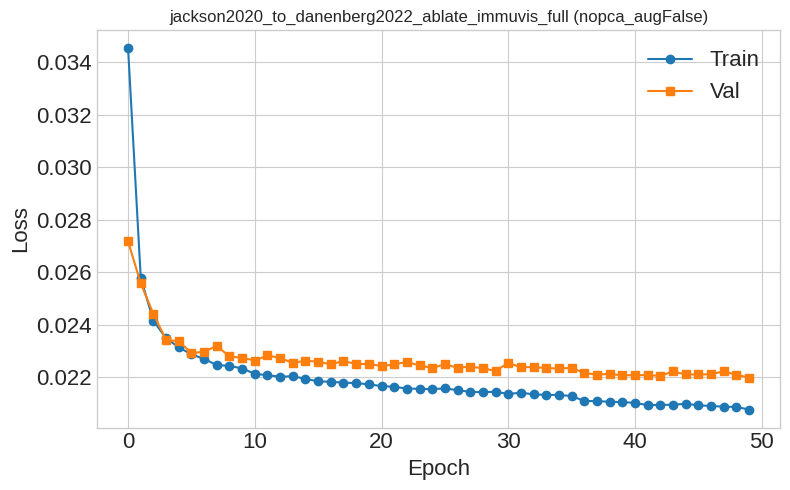

[cache] Saved model to /kaggle/working/cv_cache/model_jackson2020_to_danenberg2022_ablate_immuvis_full_nopca_augFalse.pth

========== EVAL [nopca_augFalse] marker=c_erb_b_2_her2 ==========


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  RMSE=0.2066  Pearson=0.3408  FID=181.14

========== EVAL [nopca_augFalse] marker=cd20 ==========
  RMSE=0.2341  Pearson=0.2035  FID=184.47

========== EVAL [nopca_augFalse] marker=cd3 ==========
  RMSE=0.1831  Pearson=0.1396  FID=207.46

========== EVAL [nopca_augFalse] marker=cd45 ==========
  RMSE=0.3069  Pearson=0.3906  FID=192.38

========== EVAL [nopca_augFalse] marker=cd68 ==========
  RMSE=0.1490  Pearson=0.0934  FID=249.95

========== EVAL [nopca_augFalse] marker=cytokeratin_5 ==========
  RMSE=0.1925  Pearson=0.0966  FID=277.71

========== EVAL [nopca_augFalse] marker=cytokeratin_8_18 ==========
  RMSE=0.1517  Pearson=0.3932  FID=190.91

========== EVAL [nopca_augFalse] marker=estrogen_receptor_alpha ==========
  RMSE=0.5770  Pearson=0.5135  FID=254.32

========== EVAL [nopca_augFalse] marker=ki_67 ==========
  RMSE=0.1193  Pearson=0.1328  FID=195.37

========== EVAL [nopca_augFalse] marker=pan_cytokeratin ==========
  RMSE=0.2119  Pearson=0.5383  FID=233.33

========== EVAL

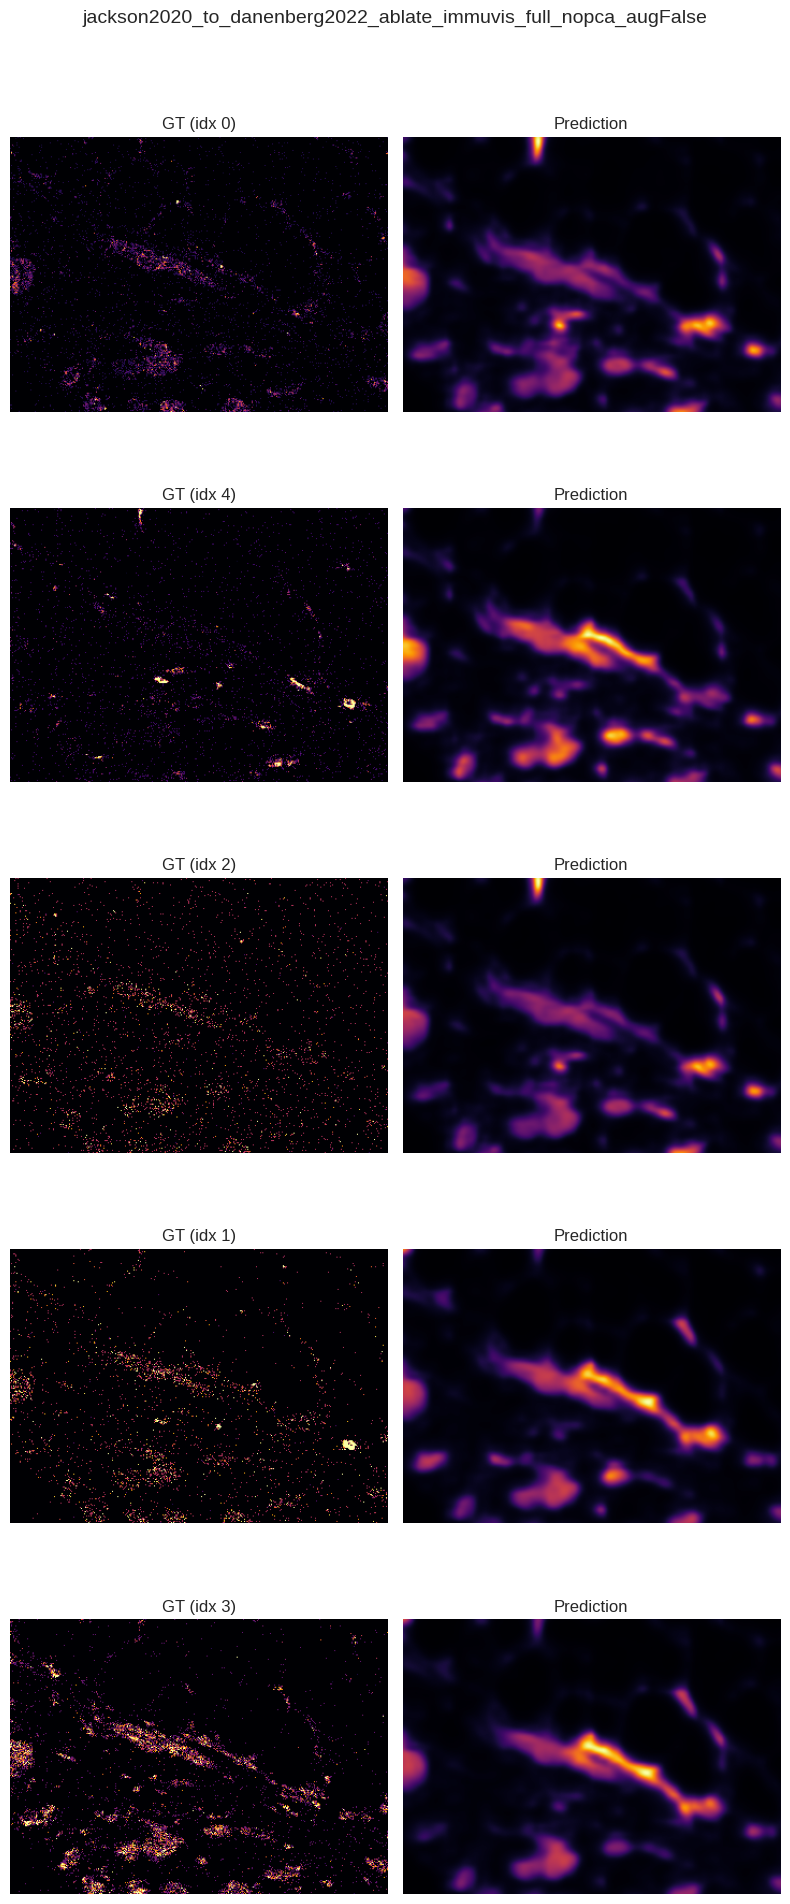

[vis] Saved comparison_jackson2020_to_danenberg2022_ablate_immuvis_full_nopca_augFalse.png
Finished arm [ablate_immuvis] in 393.0 min
[saved] /kaggle/working/cv_cache/preproc_ablation_results_full.csv  (+ablate_immuvis, mean Pearson=0.2836)

PREPROCESSING ABLATION SUMMARY (full)

--- PEARSON ---
condition                ablate_gamma  ablate_immuvis  ablate_residual
marker                                                                
c_erb_b_2_her2                 0.3620          0.3408           0.4033
cd20                           0.2566          0.2035           0.2250
cd3                            0.1255          0.1396           0.0945
cd45                           0.4104          0.3906           0.3478
cd68                           0.0705          0.0934           0.0681
cytokeratin_5                  0.0959          0.0966           0.0884
cytokeratin_8_18               0.2642          0.3932           0.2284
estrogen_receptor_alpha        0.4633          0.5135           

In [12]:
# ─── Experiment configuration: PREPROCESSING ABLATION (session_summary P1) ─────
#
# Thesis test: fix architecture (no_pca ResNetUNet, in_channels=K), training budget,
# task list, and TARGET normalisation; vary ONLY the input-channel preprocessing.
# Pearson, FID and RMSE are directly comparable across arms.
#
# CRASH-SAFETY / KAGGLE 12 h LIMIT (why the previous run died):
#   * The OOM hit when the 2nd arm allocated a fresh model on top of un-freed state.
#     -> Run ONE arm per session (set RUN_ARMS below). Finished arms are skipped.
#   * Per-arm results are appended to the CSV the moment an arm finishes, so a crash
#     never discards a completed arm.
#   * train_model checkpoints every epoch (*_resume.pkl). 50 epochs does NOT fit in
#     one 12 h session (~20-25 epochs/session); if a session times out mid-training,
#     attach THIS run's output as an input dataset (cell 3) and re-run — training
#     resumes from the last epoch. Early stopping (patience) often ends it sooner.
#   * data_name carries a 'poc'/'full' regime tag, so the real run never reuses the
#     POC smoke-test model. The epoch-independent preprocessing caches ARE reused.

shared_non_ctrl = [m for m in shared_markers if m not in set(control_names)]
all_tasks = [
    (j_idx[m], sorted([j_idx[mm] for mm in shared_non_ctrl if mm != m]))
    for m in shared_non_ctrl
]
task_names = shared_non_ctrl
print(f'Tasks (n={len(all_tasks)}): {task_names}')
print(f'K (input channels per task) = {len(all_tasks[0][1])}')

all_pred_ch = sorted({idx for _, inp in all_tasks for idx in inp})
resume = True


def _train_files():
    files = sorted(set(
        glob.glob(os.path.join(train_path, '*.tif')) +
        glob.glob(os.path.join(train_path, '*.tiff')) +
        glob.glob(os.path.join(train_path, '**', '*.tif'),  recursive=True) +
        glob.glob(os.path.join(train_path, '**', '*.tiff'), recursive=True)
    ))
    if not files:
        raise FileNotFoundError(
            f'No .tif/.tiff files under {train_path!r}. '
            f'Top-level: {os.listdir(train_path)[:20]}')
    print(f'[prepro] Found {len(files)} training files under {train_path}')
    return files


def _fit_or_load(cache_name, fit_fn, with_target=False):
    path = os.path.join(WORK_CACHE_ROOT, cache_name)
    if resume and os.path.exists(path):
        with open(path, 'rb') as fp:
            obj = pickle.load(fp)
        print(f'[prepro] Loaded {cache_name}')
        return obj
    obj = fit_fn(_train_files(), all_pred_ch, control_train, cofactor=5.0)
    with open(path, 'wb') as fp:
        pickle.dump(obj, fp)
    print(f'[prepro] Saved {cache_name}')
    return obj


# Epoch-independent preprocessing caches (reused across POC and full runs)
channel_preproc_residual, target_norm_stats = _fit_or_load(
    'channel_preproc_residual.pkl', fit_channel_preprocessing, with_target=True)
channel_preproc_gamma   = _fit_or_load('channel_preproc_gamma.pkl',   fit_gamma_preprocessing)
channel_preproc_immuvis = _fit_or_load('channel_preproc_immuvis.pkl', fit_immuvis_preprocessing)

# ── Ablation arms (architecture fixed = no_pca; vary preprocessing only) ────────
ALL_ARMS = {
    'ablate_residual': {'preproc': 'residual', 'stats': channel_preproc_residual},
    'ablate_gamma':    {'preproc': 'gamma',    'stats': channel_preproc_gamma},
    'ablate_immuvis':  {'preproc': 'immuvis',  'stats': channel_preproc_immuvis},
}
# >>> ONE ARM PER KAGGLE SESSION — edit this line each session <<<
RUN_ARMS = ['ablate_immuvis']          # next sessions: ['ablate_gamma'], then ['ablate_immuvis']
arms = [{'label': k, **ALL_ARMS[k]} for k in RUN_ARMS]

# Full-training settings (POC_MODE=False): 50-epoch cap with early stopping.
# bs/nw match the POC config that ran the residual arm for 5.6 h without OOM.
regime = 'poc' if POC_MODE else 'full'
bs  = poc_cfg['batch_size']  if POC_MODE else 8
nw  = poc_cfg['num_workers'] if POC_MODE else 2
ep  = poc_cfg['epochs']      if POC_MODE else 50
pat = poc_cfg['patience']    if POC_MODE else 8
lrp = poc_cfg['lr_patience'] if POC_MODE else 5
print(f'[cfg] regime={regime} bs={bs} nw={nw} epochs={ep} patience={pat} lr_patience={lrp}')
print(f'[cfg] running arms this session: {RUN_ARMS}')

out_csv = os.path.join(WORK_CACHE_ROOT, f'preproc_ablation_results_{regime}.csv')


def _done_conditions():
    if os.path.exists(out_csv):
        return set(pd.read_csv(out_csv)['condition'].unique())
    return set()


for arm in arms:
    if arm['label'] in _done_conditions():
        print(f"[skip] {arm['label']} already present in {out_csv}")
        continue
    print(f"\n{'='*25}\nARM: {arm['label']}  (preproc={arm['preproc']}, regime={regime})\n{'='*25}")
    t0 = time.time()
    per_marker = main_multitask(
        path=train_path,
        tasks=all_tasks,
        task_names=task_names,
        channel_preproc=arm['stats'],
        target_norm_stats=target_norm_stats,
        control_indices=control_train,
        data_name=f'{train_dataset}_to_{test_dataset}_{arm["label"]}_{regime}',
        cache_dir=WORK_CACHE_ROOT,
        batch_size=bs, num_workers=nw, epochs=ep, patience=pat, lr_patience=lrp,
        cofactor=5.0,
        test_path=test_path,
        test_index_map=train_to_test_index_map,
        use_hyperconv=False,
        augment=False,
        preproc=arm['preproc'],
        marker_vocab_size=len(j_markers),
    )
    print(f"Finished arm [{arm['label']}] in {(time.time()-t0)/60:.1f} min")

    # Append this arm's results immediately (crash-safe).
    arm_rows = pd.DataFrame([
        {'condition': arm['label'], 'marker': mk,
         'rmse': m['rmse'], 'pearson': m['pearson'], 'fid': m['fid']}
        for mk, m in per_marker.items()
    ])
    if os.path.exists(out_csv):
        prev = pd.read_csv(out_csv)
        prev = prev[prev['condition'] != arm['label']]      # replace on rerun
        arm_rows = pd.concat([prev, arm_rows], ignore_index=True)
    arm_rows.to_csv(out_csv, index=False)
    mean_p = arm_rows[arm_rows['condition'] == arm['label']]['pearson'].mean()
    print(f"[saved] {out_csv}  (+{arm['label']}, mean Pearson={mean_p:.4f})")
    del per_marker; torch.cuda.empty_cache(); gc.collect()

# ─── Summary across all arms completed so far (this + previous sessions) ────────
if os.path.exists(out_csv):
    results_df = pd.read_csv(out_csv)
    print("\n" + "=" * 60 + f"\nPREPROCESSING ABLATION SUMMARY ({regime})\n" + "=" * 60)
    for metric in ['pearson', 'fid', 'rmse']:
        print(f"\n--- {metric.upper()} ---")
        pivot = results_df.pivot_table(index='marker', columns='condition', values=metric)
        print(pivot.round(4).to_string())
        print('mean:', pivot.mean().round(4).to_dict())


# Experiment 1 — Abundance vs Structure (between / within-image decomposition)

**Inference only.** Loads an existing Jackson→Danenberg checkpoint (no retraining) and, for the
focus markers, splits the pixel-level Pearson three ways to test whether a high pooled
correlation reflects recovered spatial biology or merely recovered per-image abundance.

- **Pooled** — the current headline number (all pixels of all images, means never removed).
- **Between-image** — Pearson of the per-image means: does the model rank images/patients high↔low?
- **Within-image** — after subtracting each image's own mean. Reported two ways:
  *pooled-after-centering* and *median per-image*.

All metrics are functions of per-image sufficient statistics (n, Σg, Σp, Σg², Σp², Σgp), so the
expensive inference pass is run **once** per marker and every metric + bootstrap is cheap
arithmetic on those stats. A **variance/covariance identity check** confirms
`total = between + within` (holds exactly for covariance and each variance).

**Bootstrap unit** is *patient* if image→patient can be recovered (from `PATIENT_META_CSV` or the
filename), otherwise *image* — the cell prints which was used, as pre-registered.

**The flip we're hunting:** ERα high on pooled **and** between-image but low on within-image, while
panCK (the control) stays high on all three. If it appears, ERα is "imputable" only in the
abundance sense — which is exactly the claim the panel-design story must not overstate.

Focus markers: `estrogen_receptor_alpha` (main test), `c_erb_b_2_her2` (backup),
`pan_cytokeratin` (should stay good — the comparison).

In [ ]:
# ─── EXPERIMENT 1: Abundance vs Structure ─────────────────────────────────────
# Inference-only decomposition of the pixel Pearson into between-image (abundance)
# and within-image (spatial) components. Relies on globals defined above:
#   ResNetUNet, MultiTaskDataset, pad_collate, smart_load_state_dict, all_tasks,
#   task_names, train_to_test_index_map, control_train, target_norm_stats,
#   test_path, WORK_CACHE_ROOT, train_dataset, test_dataset, channel_preproc_*.
import re, os, glob
import numpy as np, pandas as pd, torch
from torch.utils.data import DataLoader
from torch.amp import autocast

# ── CONFIG ────────────────────────────────────────────────────────────────────
E1_ARM    = 'ablate_residual'   # checkpoint to analyse. Strongest ERa in-family
                                #   -> strongest possible case for the flip.
                                #   Options: 'ablate_residual' | 'ablate_gamma' | 'ablate_immuvis'
E1_REGIME = 'full'
E1_FOCUS  = ['estrogen_receptor_alpha',  # ERa   — main test
             'c_erb_b_2_her2',           # HER2  — backup
             'pan_cytokeratin']          # panCK — control (should stay good)
E1_NBOOT  = 1000
E1_SEED   = 0
# Optional image->patient map: CSV with columns [filename, patient] (filename = basename).
# Leave None to parse a METABRIC id (MB-####) from the filename instead.
PATIENT_META_CSV = None

_ARM_PREPROC = {
    'ablate_residual': ('residual', channel_preproc_residual),
    'ablate_gamma':    ('gamma',    channel_preproc_gamma),
    'ablate_immuvis':  ('immuvis',  channel_preproc_immuvis),
}
preproc_name, channel_preproc = _ARM_PREPROC[E1_ARM]
data_name = f'{train_dataset}_to_{test_dataset}_{E1_ARM}_{E1_REGIME}'
model_tag = 'nopca_augFalse'
ckpt_path = os.path.join(WORK_CACHE_ROOT, f'model_{data_name}_{model_tag}.pth')
assert os.path.exists(ckpt_path), (
    f'[E1] checkpoint not found: {ckpt_path}\n'
    f'     Available: {glob.glob(os.path.join(WORK_CACHE_ROOT, "model_*.pth"))}')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
K = len(all_tasks[0][1])
_e1_model = ResNetUNet(in_channels=K).to(device)
smart_load_state_dict(_e1_model, torch.load(ckpt_path, map_location=device))
_e1_model.eval()
print(f'[E1] loaded {os.path.basename(ckpt_path)}  (K={K}, preproc={preproc_name}, device={device})')

# ── Test files (same discovery convention as training) ─────────────────────────
test_files = sorted(set(
    glob.glob(os.path.join(test_path, '*.tif'))  + glob.glob(os.path.join(test_path, '*.tiff')) +
    glob.glob(os.path.join(test_path, '**', '*.tif'),  recursive=True) +
    glob.glob(os.path.join(test_path, '**', '*.tiff'), recursive=True)))
assert test_files, f'[E1] no .tif/.tiff under {test_path}'
print(f'[E1] {len(test_files)} test images')

# ── Patient linkage (verify before trusting patient-level CIs) ─────────────────
def _patient_from_path(p):
    base = os.path.splitext(os.path.basename(p))[0]
    m = re.search(r'MB[-_]?0*(\d{1,4})', base, re.I)   # METABRIC id e.g. MB-0362
    return f'MB-{int(m.group(1)):04d}' if m else None

if PATIENT_META_CSV and os.path.exists(PATIENT_META_CSV):
    _meta = pd.read_csv(PATIENT_META_CSV)
    _map  = {str(r['filename']): str(r['patient']) for _, r in _meta.iterrows()}
    file_patient = [_map.get(os.path.basename(f)) for f in test_files]
    _src = f'PATIENT_META_CSV ({os.path.basename(PATIENT_META_CSV)})'
else:
    file_patient = [_patient_from_path(f) for f in test_files]
    _src = 'filename regex (MB-####)'

_n_pat = len(set(p for p in file_patient if p is not None))
if all(p is not None for p in file_patient) and _n_pat > 1:
    BOOT_UNIT = 'patient'
    print(f'[E1] bootstrap unit = PATIENT  ({_n_pat} patients over {len(test_files)} images, via {_src})')
else:
    BOOT_UNIT = 'image'
    _miss = sum(p is None for p in file_patient)
    print(f'[E1] bootstrap unit = IMAGE  (could not map {_miss}/{len(test_files)} files to a '
          f'patient via {_src}; set PATIENT_META_CSV to enable patient-level CIs). '
          f'CIs below are per-image and UNDERSTATE uncertainty if images share patients.')


# ── One inference pass per marker → per-image sufficient statistics ────────────
@torch.no_grad()
def _collect_image_stats(target_idx, input_channels):
    ds = MultiTaskDataset(test_files, [(target_idx, input_channels)], channel_preproc,
                          target_norm_stats, control_train, cofactor=5.0, augment=False,
                          index_map=train_to_test_index_map, preproc=preproc_name)
    loader = DataLoader(ds, batch_size=8, shuffle=False, collate_fn=pad_collate,
                        num_workers=0, pin_memory=True)
    rows, img_i = [], 0
    for x, y, mids, orig_sizes in loader:
        x = x.to(device, non_blocking=True); y = y.to(device, non_blocking=True)
        mids = mids.to(device, non_blocking=True)
        with autocast(device_type='cuda', enabled=(device == 'cuda')):
            yhat = _e1_model(x, mids)
        for b, (h, w) in enumerate(orig_sizes):
            g = y[b, 0, :h, :w].float().reshape(-1).double()
            p = yhat[b, 0, :h, :w].clamp(0, 1).float().reshape(-1).double()
            rows.append(dict(
                file=os.path.basename(test_files[img_i]), patient=file_patient[img_i],
                n=float(g.numel()),
                Sg=g.sum().item(), Sp=p.sum().item(),
                Sgg=(g * g).sum().item(), Spp=(p * p).sum().item(), Sgp=(g * p).sum().item()))
            img_i += 1
    return pd.DataFrame(rows)


# ── Metrics from sufficient statistics (g = ground truth, p = prediction) ──────
def _metrics_from_stats(df):
    n, Sg, Sp = df['n'].values, df['Sg'].values, df['Sp'].values
    Sgg, Spp, Sgp = df['Sgg'].values, df['Spp'].values, df['Sgp'].values
    N = n.sum()
    # pooled (global-mean-centered)
    tot_cov = Sgp.sum() - Sg.sum() * Sp.sum() / N
    tot_vg  = Sgg.sum() - Sg.sum() ** 2 / N
    tot_vp  = Spp.sum() - Sp.sum() ** 2 / N
    r_pool  = tot_cov / np.sqrt(tot_vg * tot_vp) if tot_vg > 0 and tot_vp > 0 else np.nan
    # between-image (pixel-weighted covariance / variances — used for the identity)
    btw_cov = (Sg * Sp / n).sum() - Sg.sum() * Sp.sum() / N
    btw_vg  = (Sg * Sg / n).sum() - Sg.sum() ** 2 / N
    btw_vp  = (Sp * Sp / n).sum() - Sp.sum() ** 2 / N
    # within-image (pooled after centering each image)
    win_cov = (Sgp - Sg * Sp / n).sum()
    win_vg  = (Sgg - Sg * Sg / n).sum()
    win_vp  = (Spp - Sp * Sp / n).sum()
    r_within_pool = win_cov / np.sqrt(win_vg * win_vp) if win_vg > 0 and win_vp > 0 else np.nan
    # between-image correlation: UNWEIGHTED across images (does it rank images high/low)
    mg, mp = Sg / n, Sp / n
    r_between = np.corrcoef(mg, mp)[0, 1] if len(df) > 2 and np.std(mg) > 0 and np.std(mp) > 0 else np.nan
    # within-image, median of per-image Pearson
    num = n * Sgp - Sg * Sp
    den = np.sqrt(np.clip(n * Sgg - Sg * Sg, 0, None) * np.clip(n * Spp - Sp * Sp, 0, None))
    ri = np.where(den > 0, num / den, np.nan)
    r_within_med = np.nanmedian(ri)
    return dict(r_pooled=r_pool, r_between=r_between,
                r_within_pooled=r_within_pool, r_within_median=r_within_med,
                tot_cov=tot_cov, btw_cov=btw_cov, win_cov=win_cov,
                tot_vg=tot_vg, btw_vg=btw_vg, win_vg=win_vg,
                tot_vp=tot_vp, btw_vp=btw_vp, win_vp=win_vp)


def _bootstrap_ci(df, nboot, unit, seed):
    rng = np.random.default_rng(seed)
    keys = ['r_pooled', 'r_between', 'r_within_pooled', 'r_within_median']
    out = {k: [] for k in keys}
    if unit == 'patient':
        groups = df.groupby('patient').indices
        gk = list(groups.keys())
        for _ in range(nboot):
            samp = rng.choice(len(gk), len(gk), replace=True)
            rows = np.concatenate([groups[gk[i]] for i in samp])
            m = _metrics_from_stats(df.iloc[rows])
            for k in keys: out[k].append(m[k])
    else:
        idx = np.arange(len(df))
        for _ in range(nboot):
            rows = rng.choice(idx, len(idx), replace=True)
            m = _metrics_from_stats(df.iloc[rows])
            for k in keys: out[k].append(m[k])
    return {k: (np.nanpercentile(v, 2.5), np.nanpercentile(v, 97.5)) for k, v in out.items()}


# ── Run all focus markers ──────────────────────────────────────────────────────
e1_summary, e1_imgstats = [], {}
for marker in E1_FOCUS:
    if marker not in task_names:
        print(f'[E1] SKIP {marker}: not a prediction task in task_names'); continue
    ti = task_names.index(marker)
    target_idx, input_channels = all_tasks[ti]
    df = _collect_image_stats(target_idx, input_channels)
    e1_imgstats[marker] = df
    df.to_csv(os.path.join(WORK_CACHE_ROOT, f'e1_imgstats_{E1_ARM}_{marker}.csv'), index=False)

    m  = _metrics_from_stats(df)
    ci = _bootstrap_ci(df, E1_NBOOT, BOOT_UNIT, E1_SEED)

    # variance/covariance identity: total == between + within
    id_cov = m['tot_cov'] - (m['btw_cov'] + m['win_cov'])
    id_vg  = m['tot_vg']  - (m['btw_vg']  + m['win_vg'])
    id_vp  = m['tot_vp']  - (m['btw_vp']  + m['win_vp'])
    rel = lambda resid, tot: abs(resid) / abs(tot) if tot else 0.0

    print(f"\n{'='*64}\n[E1] {marker}   (arm={E1_ARM}, n_images={len(df)})\n{'='*64}")
    def _fmt(key, label):
        lo, hi = ci[key]
        print(f"  {label:<28} {m[key]:+.3f}   [{lo:+.3f}, {hi:+.3f}]")
    _fmt('r_pooled',        'pooled Pearson')
    _fmt('r_between',       'between-image (rank imgs)')
    _fmt('r_within_pooled', 'within-image (pooled-cent.)')
    _fmt('r_within_median', 'within-image (median/img)')
    print(f"  identity |total-(btw+win)|/total   "
          f"cov={rel(id_cov,m['tot_cov']):.1e}  varG={rel(id_vg,m['tot_vg']):.1e}  "
          f"varP={rel(id_vp,m['tot_vp']):.1e}   (should be ~0)")

    e1_summary.append(dict(
        marker=marker, arm=E1_ARM, n_images=len(df), boot_unit=BOOT_UNIT,
        r_pooled=m['r_pooled'], r_pooled_lo=ci['r_pooled'][0], r_pooled_hi=ci['r_pooled'][1],
        r_between=m['r_between'], r_between_lo=ci['r_between'][0], r_between_hi=ci['r_between'][1],
        r_within_pooled=m['r_within_pooled'], r_within_pooled_lo=ci['r_within_pooled'][0],
        r_within_pooled_hi=ci['r_within_pooled'][1],
        r_within_median=m['r_within_median'], r_within_median_lo=ci['r_within_median'][0],
        r_within_median_hi=ci['r_within_median'][1],
        var_between_frac_g=m['btw_vg'] / m['tot_vg'] if m['tot_vg'] else np.nan))

e1_df = pd.DataFrame(e1_summary)
e1_csv = os.path.join(WORK_CACHE_ROOT, f'e1_abundance_vs_structure_{E1_ARM}.csv')
e1_df.to_csv(e1_csv, index=False)

# ── Flip read-out (heuristic; judge against panCK) ─────────────────────────────
print(f"\n{'='*64}\n[E1] SUMMARY  (bootstrap unit = {BOOT_UNIT})\n{'='*64}")
_show = ['marker', 'r_pooled', 'r_between', 'r_within_pooled', 'r_within_median', 'var_between_frac_g']
print(e1_df[_show].round(3).to_string(index=False))
print(f"\n[E1] var_between_frac_g = fraction of ground-truth variance that is BETWEEN images "
      f"(abundance). High value + low within-image r = the flip.")
for _, r in e1_df.iterrows():
    gap = r['r_between'] - r['r_within_pooled']
    flip = (r['r_between'] > 0.3) and (r['r_within_pooled'] < 0.3) and (gap > 0.2)
    tag = 'FLIP CANDIDATE (abundance-only)' if flip else 'keeps within-image structure'
    print(f"  {r['marker']:<26} between−within = {gap:+.3f}  ->  {tag}")
print(f"\n[E1] saved: {e1_csv}")
print(f"[E1] per-image stats: {os.path.join(WORK_CACHE_ROOT, f'e1_imgstats_{E1_ARM}_<marker>.csv')} "
      f"(reusable for Experiment 2 without re-running inference)")

In [ ]:
# ─── EXPERIMENT 2: Preprocessing × Marker spatial decomposition ────────────────
# Inference-only extension of Experiment 1. Runs all 3 arms (residual/gamma/immuvis)
# × every shared prediction marker on the Danenberg test set, reusing the E1 harness
# (ResNetUNet, MultiTaskDataset, pad_collate, smart_load_state_dict).
#
# One streaming pass per (arm, marker) stores per-image sufficient statistics
# (raw sums) + true-channel signal quality; every metric and the PAIRED
# patient-clustered bootstrap are computed from those cached stats. The target
# map is identical across arms by construction, so signal quality is per-marker.
import os, re, glob, time
import numpy as np, pandas as pd, torch
from torch.utils.data import DataLoader
from torch.amp import autocast
import matplotlib.pyplot as plt

# ── CONFIG ─────────────────────────────────────────────────────────────────────
E2_REGIME  = 'full'
E2_NBOOT   = 1000
E2_SEED    = 0
E2_POS_THR = 0.05     # true (normalised, [0,1]) value above which a pixel is "positive"
E2_MIN_POS = 100      # min positive pixels for an image to count in the median within-r
E2_BS, E2_NW = 8, 2
device = 'cuda' if torch.cuda.is_available() else 'cpu'

ARMS = {  # arm -> (preproc name, fitted channel_preproc)
    'residual': ('residual', channel_preproc_residual),
    'gamma':    ('gamma',    channel_preproc_gamma),
    'immuvis':  ('immuvis',  channel_preproc_immuvis),
}
SHORT = {'c_erb_b_2_her2':'HER2','cd20':'CD20','cd3':'CD3','cd45':'CD45','cd68':'CD68',
         'cytokeratin_5':'CK5','cytokeratin_8_18':'CK8/18','estrogen_receptor_alpha':'ERa',
         'ki_67':'Ki-67','pan_cytokeratin':'panCK','sma':'SMA'}
MARKERS = list(task_names)
K = len(all_tasks[0][1])
sh = lambda m: SHORT.get(m, m)
print(f'[E2] arms={list(ARMS)}  markers(n={len(MARKERS)})={[sh(m) for m in MARKERS]}  K={K}')

# ── Test files + patient linkage (same convention as E1) ───────────────────────
test_files = sorted(set(
    glob.glob(os.path.join(test_path, '*.tif'))  + glob.glob(os.path.join(test_path, '*.tiff')) +
    glob.glob(os.path.join(test_path, '**', '*.tif'),  recursive=True) +
    glob.glob(os.path.join(test_path, '**', '*.tiff'), recursive=True)))
assert test_files, f'[E2] no .tif/.tiff under {test_path}'
def _pat(p):
    b = os.path.splitext(os.path.basename(p))[0]
    m = re.search(r'MB[-_]?0*(\d{1,4})', b, re.I)
    return f'MB-{int(m.group(1)):04d}' if m else None
file_patient = [_pat(f) for f in test_files]
_npat = len(set(p for p in file_patient if p))
BOOT_UNIT = 'patient' if (all(file_patient) and _npat > 1) else 'image'
print(f'[E2] {len(test_files)} images, {_npat} patients -> bootstrap unit = {BOOT_UNIT}')

# ── One inference pass per (arm, marker) -> per-image sufficient statistics ─────
@torch.no_grad()
def _collect(model, target_idx, input_channels, preproc_name, channel_preproc):
    ds = MultiTaskDataset(test_files, [(target_idx, input_channels)], channel_preproc,
                          target_norm_stats, control_train, cofactor=5.0, augment=False,
                          index_map=train_to_test_index_map, preproc=preproc_name)
    loader = DataLoader(ds, batch_size=E2_BS, shuffle=False, collate_fn=pad_collate,
                        num_workers=E2_NW, pin_memory=True)
    rows, i = [], 0
    for x, y, mids, sizes in loader:
        x = x.to(device, non_blocking=True); y = y.to(device, non_blocking=True)
        mids = mids.to(device, non_blocking=True)
        with autocast(device_type='cuda', enabled=(device == 'cuda')):
            yhat = model(x, mids)
        for b, (h, w) in enumerate(sizes):
            g = y[b, 0, :h, :w].float().reshape(-1).double()
            p = yhat[b, 0, :h, :w].clamp(0, 1).float().reshape(-1).double()
            n = float(g.numel())
            rows.append(dict(
                file=os.path.basename(test_files[i]), patient=file_patient[i], n=n,
                Sg=g.sum().item(), Sp=p.sum().item(),
                Sgg=(g * g).sum().item(), Spp=(p * p).sum().item(), Sgp=(g * p).sum().item(),
                pos=float((g > E2_POS_THR).sum().item()),
                gmax=g.max().item(), gmin=g.min().item()))
            i += 1
    return pd.DataFrame(rows)

# collect (or load cache) for every (arm, marker) cell; dfs stay aligned by image order
CELLS = {}
t0 = time.time()
for arm, (pname, cprep) in ARMS.items():
    ckpt = os.path.join(WORK_CACHE_ROOT,
                        f'model_{train_dataset}_to_{test_dataset}_ablate_{arm}_{E2_REGIME}_nopca_augFalse.pth')
    assert os.path.exists(ckpt), f'[E2] missing checkpoint {ckpt}'
    model = ResNetUNet(in_channels=K).to(device)
    smart_load_state_dict(model, torch.load(ckpt, map_location=device)); model.eval()
    print(f'[E2] loaded {arm}: {os.path.basename(ckpt)}')
    for m in MARKERS:
        cache = os.path.join(WORK_CACHE_ROOT, f'e2_imgstats_{arm}_{m}.csv')
        if os.path.exists(cache):
            df = pd.read_csv(cache)
        else:
            ti = task_names.index(m); tgt, inp = all_tasks[ti]
            df = _collect(model, tgt, inp, pname, cprep); df.to_csv(cache, index=False)
        CELLS[(arm, m)] = df
    del model; torch.cuda.empty_cache()
    print(f'    [{arm}] collected {len(MARKERS)} markers  (cumulative {(time.time()-t0)/60:.1f} min)')
print(f'[E2] inference/collect done in {(time.time()-t0)/60:.1f} min')

# ── Derived per-image arrays for a cell ────────────────────────────────────────
def _cell_arrays(df):
    a = {k: df[k].values.astype(np.float64) for k in
         ['n','Sg','Sp','Sgg','Spp','Sgp','pos','gmax','gmin']}
    n = a['n']
    a['mg'], a['mp'] = a['Sg']/n, a['Sp']/n
    a['wc']  = a['Sgp'] - a['Sg']*a['Sp']/n           # within centered cov (per image)
    a['wvg'] = a['Sgg'] - a['Sg']*a['Sg']/n
    a['wvp'] = a['Spp'] - a['Sp']*a['Sp']/n
    num = n*a['Sgp'] - a['Sg']*a['Sp']
    den = np.sqrt(np.clip(n*a['Sgg']-a['Sg']**2, 0, None) * np.clip(n*a['Spp']-a['Sp']**2, 0, None))
    a['ri']    = np.where(den > 0, num/den, np.nan)   # per-image within r
    a['valid'] = (den > 0) & (a['pos'] >= E2_MIN_POS)
    var_t = np.clip(a['Sgg']/n - a['mg']**2, 0, None)
    a['snr']     = np.where(var_t > 0, a['mg']/np.sqrt(np.clip(var_t, 1e-12, None)), np.nan)
    a['posfrac'] = a['pos']/n
    a['dyn']     = a['gmax'] - a['gmin']
    return a

# ── All metrics for a resampled row set (rows: image idx w/ repeats; slot: patient-replicate id)
def _metrics(a, rows, slot):
    n=a['n'][rows]; Sg=a['Sg'][rows]; Sp=a['Sp'][rows]
    Sgg=a['Sgg'][rows]; Spp=a['Spp'][rows]; Sgp=a['Sgp'][rows]; N=n.sum()
    tot_cov = Sgp.sum() - Sg.sum()*Sp.sum()/N
    tot_vg  = Sgg.sum() - Sg.sum()**2/N
    tot_vp  = Spp.sum() - Sp.sum()**2/N
    r_pool  = tot_cov/np.sqrt(tot_vg*tot_vp) if tot_vg>0 and tot_vp>0 else np.nan
    mg, mp  = a['mg'][rows], a['mp'][rows]
    r_bimg  = np.corrcoef(mg, mp)[0,1] if len(rows)>2 and mg.std()>0 and mp.std()>0 else np.nan
    P = int(slot.max())+1
    pn = np.bincount(slot, weights=n,  minlength=P)
    pg = np.bincount(slot, weights=Sg, minlength=P)
    pp = np.bincount(slot, weights=Sp, minlength=P)
    ok = pn > 0; pmg = pg[ok]/pn[ok]; pmp = pp[ok]/pn[ok]
    r_bpat = np.corrcoef(pmg, pmp)[0,1] if ok.sum()>2 and pmg.std()>0 and pmp.std()>0 else np.nan
    win_cov=a['wc'][rows].sum(); win_vg=a['wvg'][rows].sum(); win_vp=a['wvp'][rows].sum()
    r_wpool = win_cov/np.sqrt(win_vg*win_vp) if win_vg>0 and win_vp>0 else np.nan
    v = a['valid'][rows]
    r_wmed = np.nanmedian(a['ri'][rows][v]) if v.any() else np.nan
    btw_vg = (Sg*Sg/n).sum() - Sg.sum()**2/N
    vbf    = btw_vg/tot_vg if tot_vg>0 else np.nan
    btw_cov= (Sg*Sp/n).sum() - Sg.sum()*Sp.sum()/N
    idrel  = abs(tot_cov-(btw_cov+win_cov))/abs(tot_cov) if tot_cov else 0.0
    return dict(r_pooled=r_pool, r_between_img=r_bimg, r_between_pat=r_bpat,
                r_within_pooled=r_wpool, r_within_median=r_wmed,
                var_between_frac=vbf, id_rel=idrel)

# ── Patient groups (aligned across all cells) ──────────────────────────────────
labs = np.array(file_patient); uniq = list(pd.unique(labs))
code = np.array([uniq.index(p) for p in labs]); Ppat = len(uniq)
groups = [np.where(code == i)[0] for i in range(Ppat)]
rows0 = np.arange(len(test_files))

arrs  = {k: _cell_arrays(CELLS[k]) for k in CELLS}
point = {k: _metrics(arrs[k], rows0, code) for k in CELLS}

# ── PAIRED patient-clustered bootstrap ─────────────────────────────────────────
MET   = ['r_pooled','r_between_img','r_between_pat','r_within_pooled','r_within_median','var_between_frac']
PAIRS = [('residual','gamma'), ('residual','immuvis'), ('gamma','immuvis')]
boot  = {k: {mm: [] for mm in MET} for k in CELLS}
did   = {(A,B,m): [] for (A,B) in PAIRS for m in MARKERS}
rng   = np.random.default_rng(E2_SEED)
tb = time.time()
for _ in range(E2_NBOOT):
    draw = rng.integers(0, Ppat, Ppat)
    rows = np.concatenate([groups[d] for d in draw])
    slot = np.concatenate([np.full(len(groups[d]), s, dtype=np.int64) for s, d in enumerate(draw)])
    per  = {k: _metrics(arrs[k], rows, slot) for k in CELLS}
    for k in CELLS:
        for mm in MET: boot[k][mm].append(per[k][mm])
    for (A,B) in PAIRS:
        for m in MARKERS:
            d = ((per[(A,m)]['r_within_pooled'] - per[(B,m)]['r_within_pooled'])
                 - (per[(A,m)]['r_between_img'] - per[(B,m)]['r_between_img']))
            did[(A,B,m)].append(d)
print(f'[E2] bootstrap ({E2_NBOOT}x, paired) done in {(time.time()-tb)/60:.1f} min')

def _ci(v):
    v = np.asarray(v, float)
    return (float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5)))

# ── 33-row table (arm x marker) ────────────────────────────────────────────────
recs = []
for arm, _ in ARMS.items():
    for m in MARKERS:
        k = (arm, m); pt = point[k]; a = arrs[k]
        row = dict(arm=arm, marker=sh(m), n_images=len(CELLS[k]), n_patients=Ppat,
                   pos_frac=float(np.nanmedian(a['posfrac'])),
                   snr=float(np.nanmedian(a['snr'])),
                   dyn_range=float(np.nanmedian(a['dyn'])),
                   id_rel=pt['id_rel'])
        for mm in MET:
            lo, hi = _ci(boot[k][mm])
            row[mm] = pt[mm]; row[mm+'_lo'] = lo; row[mm+'_hi'] = hi
        w, bimg = pt['r_within_pooled'], pt['r_between_img']
        row['fails_both']        = bool((w < 0.1) and (bimg < 0.1))
        row['abundance_leaning'] = bool((w < 0.1) and (bimg > 0.3))
        recs.append(row)
e2 = pd.DataFrame(recs)
e2_csv = os.path.join(WORK_CACHE_ROOT, 'e2_arm_marker_table.csv')
e2.to_csv(e2_csv, index=False)

# ── DiD contrasts table ────────────────────────────────────────────────────────
drecs = []
for (A,B) in PAIRS:
    for m in MARKERS:
        pt = did[(A,B,m)]
        d0 = ((point[(A,m)]['r_within_pooled'] - point[(B,m)]['r_within_pooled'])
              - (point[(A,m)]['r_between_img'] - point[(B,m)]['r_between_img']))
        lo, hi = _ci(pt)
        drecs.append(dict(pair=f'{A}-{B}', marker=sh(m), delta=d0, lo=lo, hi=hi,
                          spatial_separation=bool((lo > 0) and (abs(d0) >= 0.05))))
did_df = pd.DataFrame(drecs)
did_csv = os.path.join(WORK_CACHE_ROOT, 'e2_did_contrasts.csv')
did_df.to_csv(did_csv, index=False)

# ── Console summary ────────────────────────────────────────────────────────────
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
print('\n' + '='*84 + f'\n[E2] ARM x MARKER  (pooled / between-img / between-pat / within-pooled / within-med)\n' + '='*84)
show = ['arm','marker','r_pooled','r_between_img','r_between_pat','r_within_pooled',
        'r_within_median','var_between_frac','pos_frac','snr','id_rel']
print(e2[show].round(3).to_string(index=False))
print(f'\n[E2] max covariance-identity residual across cells = {e2["id_rel"].max():.1e} (should be ~0)')

print('\n' + '='*84 + '\n[E2] DiD contrasts   Delta = (within_A - within_B) - (between_A - between_B)\n' + '='*84)
print(did_df.round(3).to_string(index=False))
sep = did_df[did_df['spatial_separation']]
print('\n[E2] Spatial-separation bar met (CI>0 and |Delta|>=0.05):',
      'NONE' if sep.empty else '')
for _, r in sep.iterrows():
    print(f'    {r["pair"]:18s} {r["marker"]:7s}  Delta={r["delta"]:+.3f}  [{r["lo"]:+.3f}, {r["hi"]:+.3f}]')

fb = e2[e2['fails_both']]; al = e2[e2['abundance_leaning']]
print('\n[E2] fails both (within<0.1 & between<0.1):',
      'none' if fb.empty else ', '.join(f'{r.arm}/{r.marker}' for r in fb.itertuples()))
print('[E2] abundance-leaning flag (within<0.1 & between>0.3; judge vs signal quality):',
      'none' if al.empty else ', '.join(f'{r.arm}/{r.marker}(pos={r.pos_frac:.2f})' for r in al.itertuples()))

# predictability tiers by mean within-pooled r across arms
mw = e2.groupby('marker')['r_within_pooled'].mean().sort_values(ascending=False)
def _tier(v): return 'HIGH' if v>=0.4 else ('MID' if v>=0.2 else 'LOW')
print('\n[E2] predictability tiers (mean within-image pooled r across arms):')
for m, v in mw.items(): print(f'    {m:7s}  within_r={v:.3f}  [{_tier(v)}]')

# ── Plots ──────────────────────────────────────────────────────────────────────
arm_list = list(ARMS); mk_list = [sh(m) for m in MARKERS]

# (1) predictability map: within-pooled r, markers x arms
W = np.array([[e2[(e2.arm==arm)&(e2.marker==sh(m))]['r_within_pooled'].values[0]
               for arm in arm_list] for m in MARKERS])
fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(W, aspect='auto', cmap='viridis', vmin=0, vmax=max(0.6, np.nanmax(W)))
ax.set_xticks(range(len(arm_list))); ax.set_xticklabels(arm_list, fontsize=12)
ax.set_yticks(range(len(MARKERS))); ax.set_yticklabels(mk_list, fontsize=12)
ax.set_title('Predictability map: within-image pooled r', fontsize=13)
for i in range(len(MARKERS)):
    for j in range(len(arm_list)):
        ax.text(j, i, f'{W[i,j]:.2f}', ha='center', va='center',
                color='w' if W[i,j] < 0.35 else 'k', fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout(); fig.savefig(os.path.join(WORK_CACHE_ROOT, 'e2_predictability_map.png'), dpi=150)
plt.show(); plt.close(fig)

# (2) within vs between per arm
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)
for ax, arm in zip(axs, arm_list):
    sub = e2[e2.arm == arm]
    ax.scatter(sub['r_between_img'], sub['r_within_pooled'], s=60, color='#1f77b4')
    for _, r in sub.iterrows():
        ax.annotate(r['marker'], (r['r_between_img'], r['r_within_pooled']),
                    fontsize=10, xytext=(4, 4), textcoords='offset points')
    ax.plot([-0.1, 1], [-0.1, 1], ls='--', color='grey', lw=1)
    ax.axhline(0.1, color='r', ls=':', lw=1); ax.axvline(0.3, color='r', ls=':', lw=1)
    ax.set_title(arm, fontsize=13); ax.set_xlabel('between-image r'); ax.set_xlim(-0.05, 1)
    ax.set_ylim(-0.05, 0.8)
axs[0].set_ylabel('within-image pooled r')
fig.suptitle('Within- vs between-image correlation per arm', fontsize=15)
fig.tight_layout(); fig.savefig(os.path.join(WORK_CACHE_ROOT, 'e2_within_vs_between.png'), dpi=150)
plt.show(); plt.close(fig)

# (3) DiD forest per pair
fig, axs = plt.subplots(1, 3, figsize=(18, 7), sharex=True)
for ax, (A, B) in zip(axs, PAIRS):
    sub = did_df[did_df['pair'] == f'{A}-{B}'].reset_index(drop=True)
    yv = np.arange(len(sub))
    ax.errorbar(sub['delta'], yv,
                xerr=[sub['delta']-sub['lo'], sub['hi']-sub['delta']],
                fmt='o', color='#333', ecolor='#888', capsize=3)
    ax.axvline(0, color='k', lw=1); ax.axvline(0.05, color='r', ls=':', lw=1)
    ax.axvline(-0.05, color='r', ls=':', lw=1)
    ax.set_yticks(yv); ax.set_yticklabels(sub['marker'], fontsize=10)
    ax.set_title(f'{A} - {B}', fontsize=13); ax.set_xlabel('Delta (within-diff - between-diff)')
fig.suptitle('Difference-in-differences contrasts (95% patient-bootstrap CI)', fontsize=15)
fig.tight_layout(); fig.savefig(os.path.join(WORK_CACHE_ROOT, 'e2_did_forest.png'), dpi=150)
plt.show(); plt.close(fig)

print(f'\n[E2] saved: {e2_csv}')
print(f'[E2] saved: {did_csv}')
print('[E2] saved plots: e2_predictability_map.png, e2_within_vs_between.png, e2_did_forest.png')
